In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import missingno as msno

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
translation = pd.read_csv("product_category_name_translation.csv")

datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Products": products,
    "Payments": payments,
    "Reviews": reviews,
    "Sellers": sellers,
    "Geolocation": geolocation,
    "Translation": translation
}

summary = pd.DataFrame({
    "Dataset":[name for name in datasets.keys()],
    "Rows":[df.shape[0] for df in datasets.values()],
    "Columns":[df.shape[1] for df in datasets.values()]
})

summary

,Dataset,Rows,Columns
0,Customers,99441,5
1,Orders,99441,8
2,Order Items,112650,7
3,Products,32951,9
4,Payments,103886,5
5,Reviews,99224,7
6,Sellers,3095,4
7,Geolocation,1000163,5
8,Translation,71,2


In [36]:
pip install missingno 


Note: you may need to restart the kernel to use updated packages.


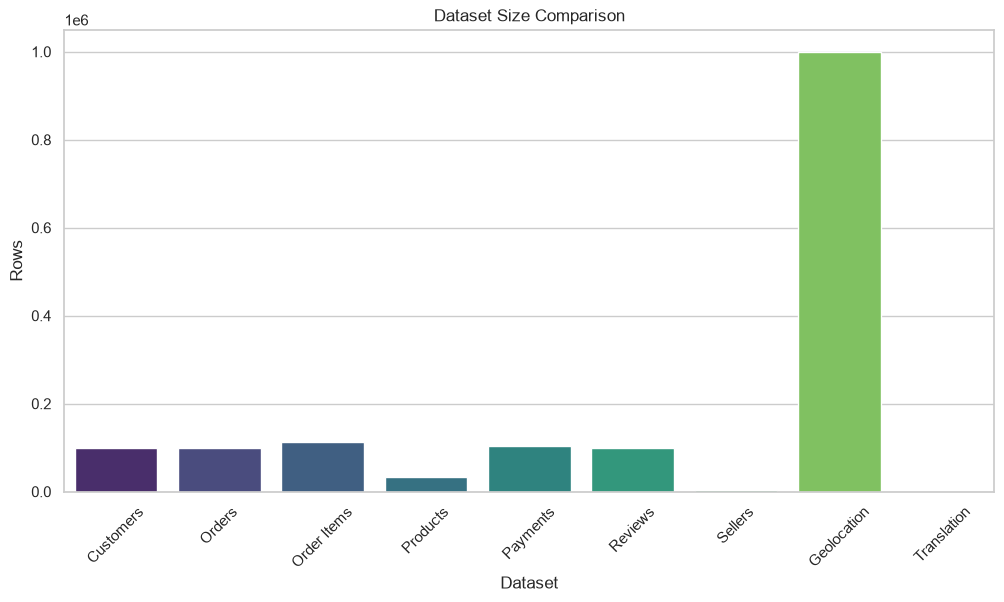

In [37]:
#Visualize Dataset Size
plt.figure(figsize=(12,6))

sns.barplot(
    data=summary,
    x="Dataset",
    y="Rows",
    palette="viridis"
)

plt.xticks(rotation=45)

plt.title("Dataset Size Comparison")

plt.show()

In [38]:
#table info
for name, df in datasets.items():

    print("="*60)

    print(name)

    print("="*60)

    display(df.head())

    print(df.info())

    print(df.describe(include='all'))

Customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
None
                             customer_id                customer_unique_id  \
count                              99441                             99441   
unique                             99441                             96096   
top     06b8999e2fba1a1fbc88172c00ba8bc7  8d50f5eadf50201ccdcedfb9e2ac8455   
freq                                   1                                17   
mean                                 NaN                               NaN   
std          

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB
None
                                order_id                       customer_id  \
count                              99441                             99441   
unique                             99441                             99441   
top     e481f51cbdc54678b7cc49136f2d6af7  9ef432

...

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB
None
                               seller_id  seller_zip_code_prefix seller_city  \
count                               3095             3095.000000        3095   
unique                              3095                     NaN         611   
top     3442f8959a84dea7ee197c632cb2df15                     NaN   sao paulo   
freq                                   1                     NaN         694   
mean                                 NaN            32291.059451         NaN   
std                                  NaN            32713.453830   

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB
None
        geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
count                  1.000163e+06     1.000163e+06     1.000163e+06   
unique                          NaN              NaN              NaN   
top                             NaN              NaN              NaN   
freq                            NaN              NaN              NaN   
mean                   3.657417e+04    -2.117615e+

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB
None
       product_category_name product_category_name_english
count                     71                            71
unique                    71                            71
top             beleza_saude                 health_beauty
freq                       1                             1


In [39]:
#check dattypes 
dtype_summary = []

for name, df in datasets.items():

    dtype_summary.append({

        "Dataset":name,

        "Numerical":len(df.select_dtypes(include=np.number).columns),

        "Categorical":len(df.select_dtypes(include='object').columns),

        "Datetime":len(df.select_dtypes(include='datetime').columns)

    })

dtype_summary = pd.DataFrame(dtype_summary)

dtype_summary

,Dataset,Numerical,Categorical,Datetime
0,Customers,1,4,0
1,Orders,0,8,0
2,Order Items,3,4,0
3,Products,7,2,0
4,Payments,3,2,0
5,Reviews,1,6,0
6,Sellers,1,3,0
7,Geolocation,3,2,0
8,Translation,0,2,0


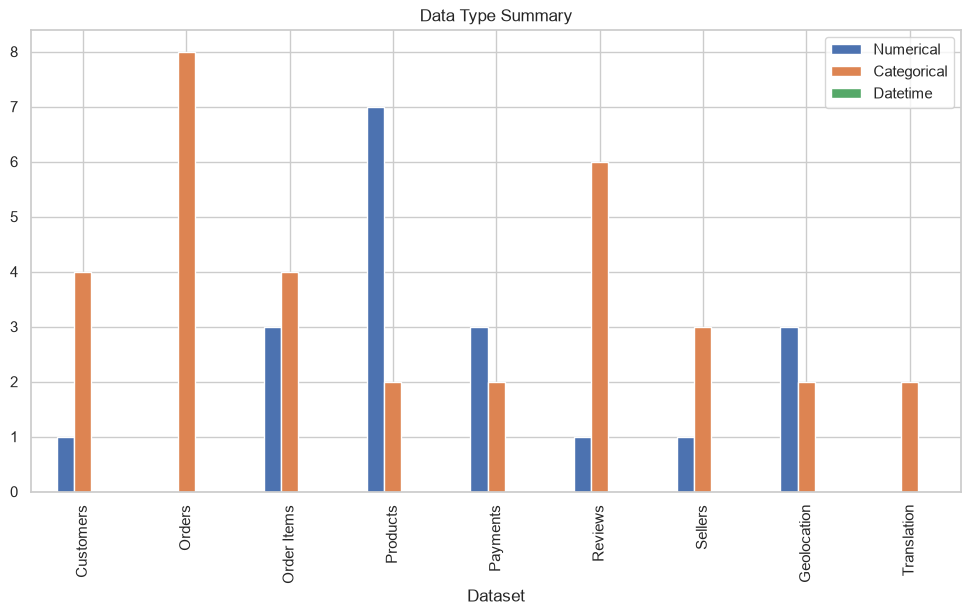

In [40]:

#Visualization
dtype_summary.set_index("Dataset").plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Data Type Summary")

plt.show()

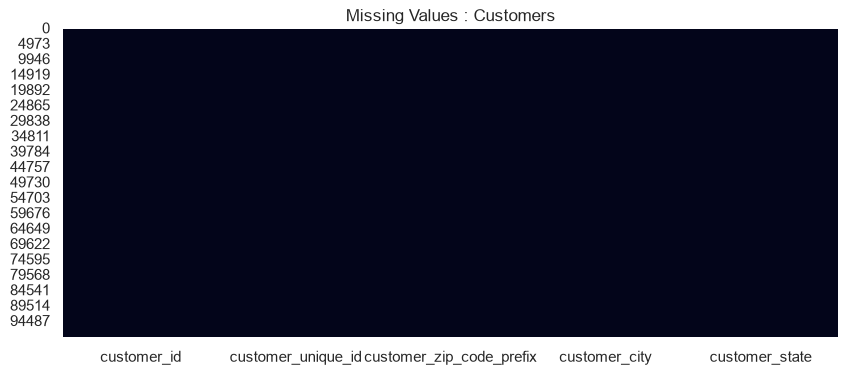

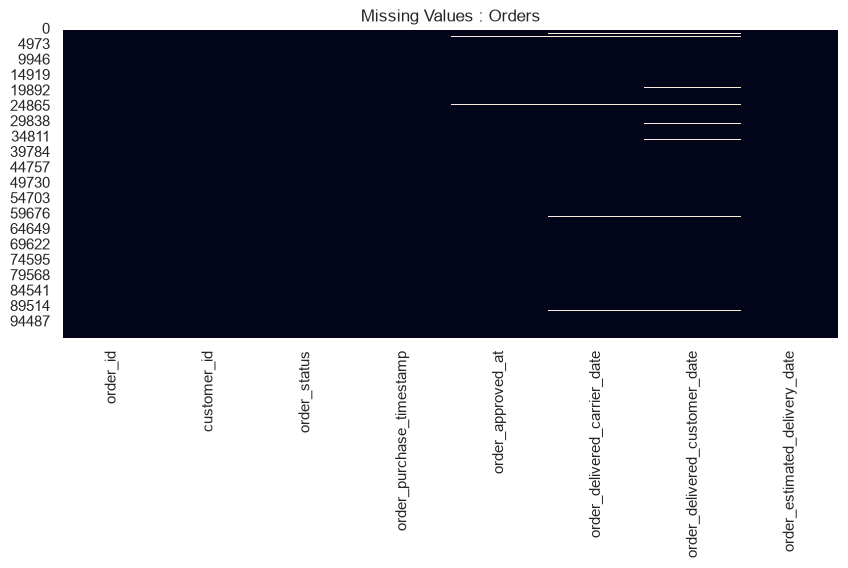

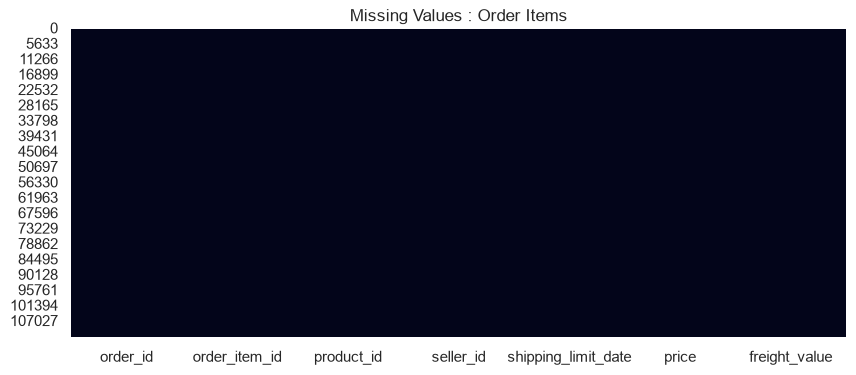

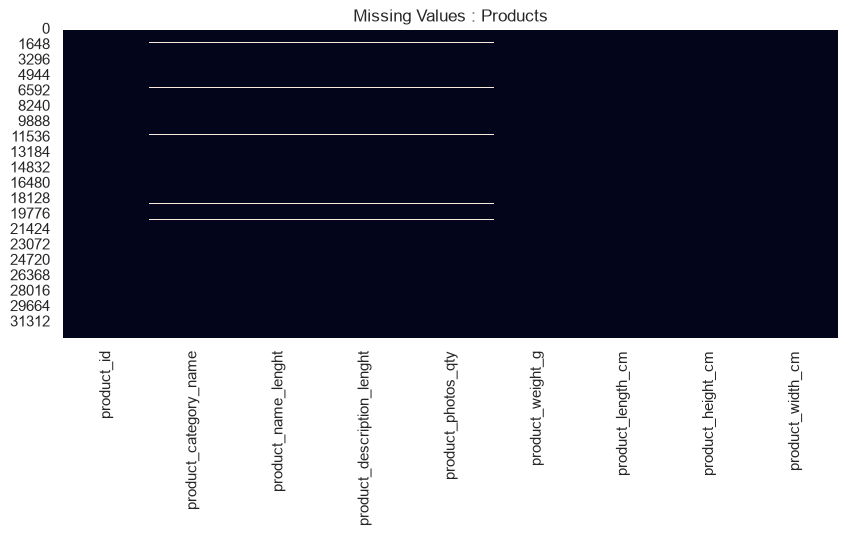

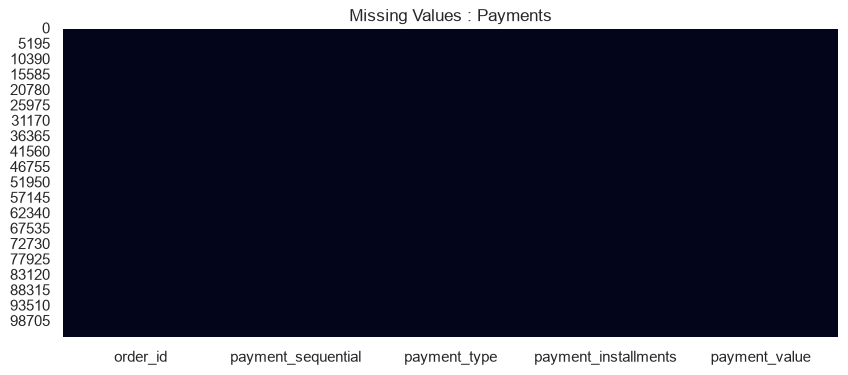

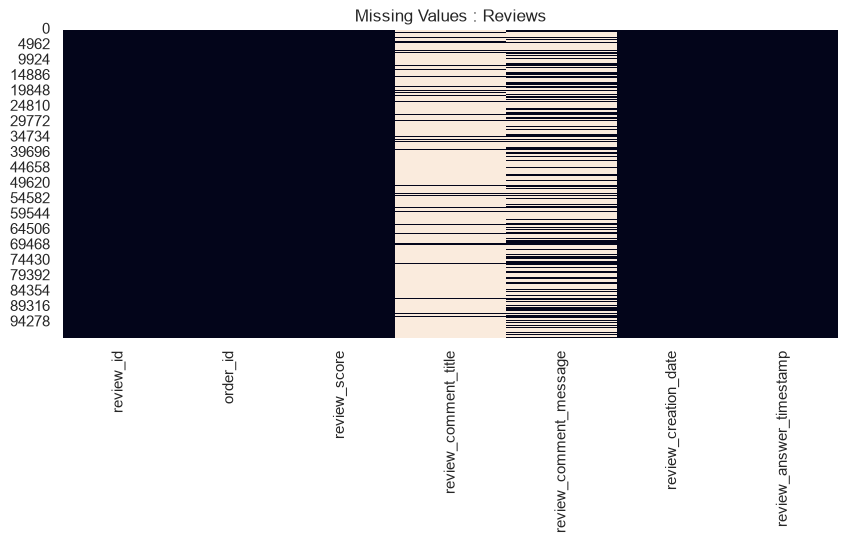

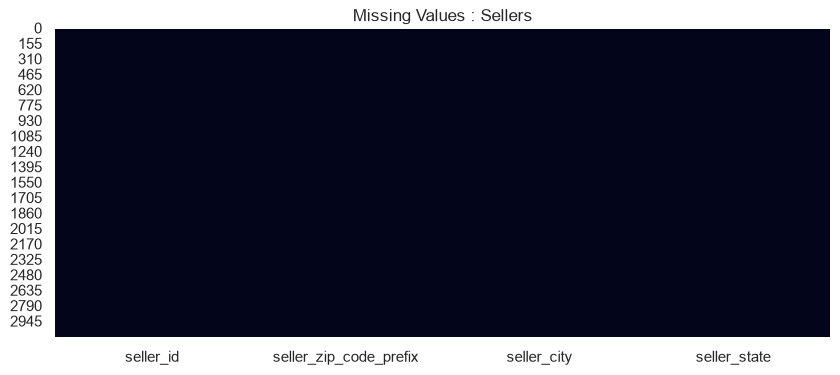

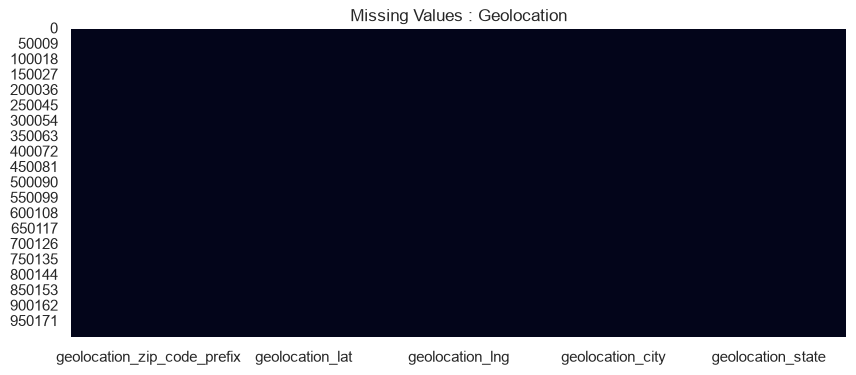

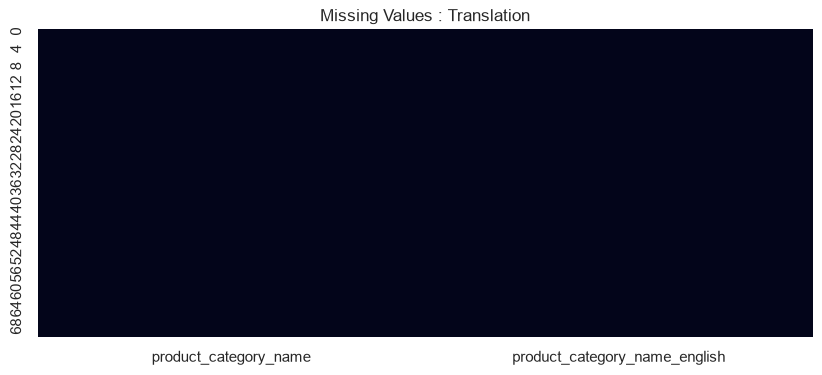

In [41]:
#Missing Values
for name, df in datasets.items():

    plt.figure(figsize=(10,4))

    sns.heatmap(
        df.isnull(),
        cbar=False
    )

    plt.title(f"Missing Values : {name}")

    plt.show()

<Figure size 1200x500 with 0 Axes>

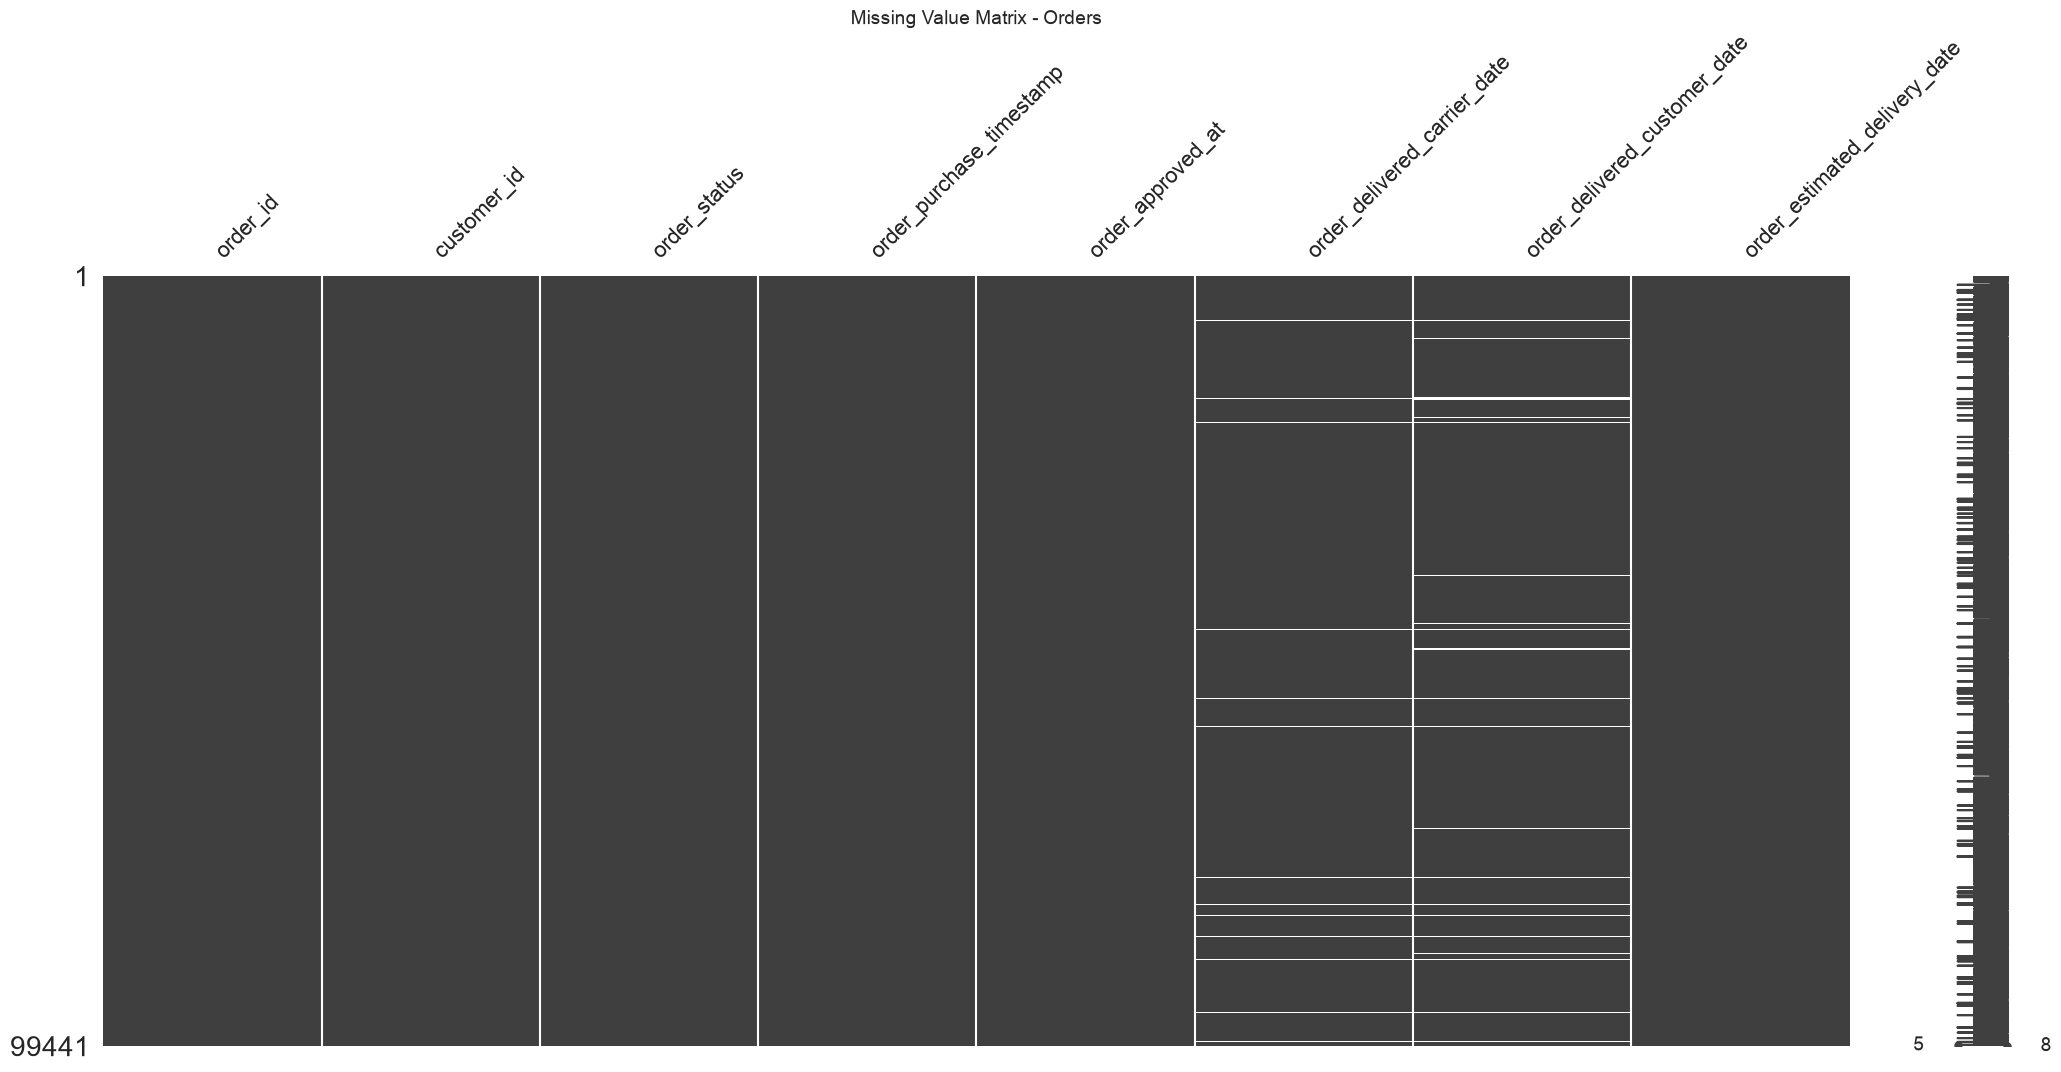

<Figure size 1200x500 with 0 Axes>

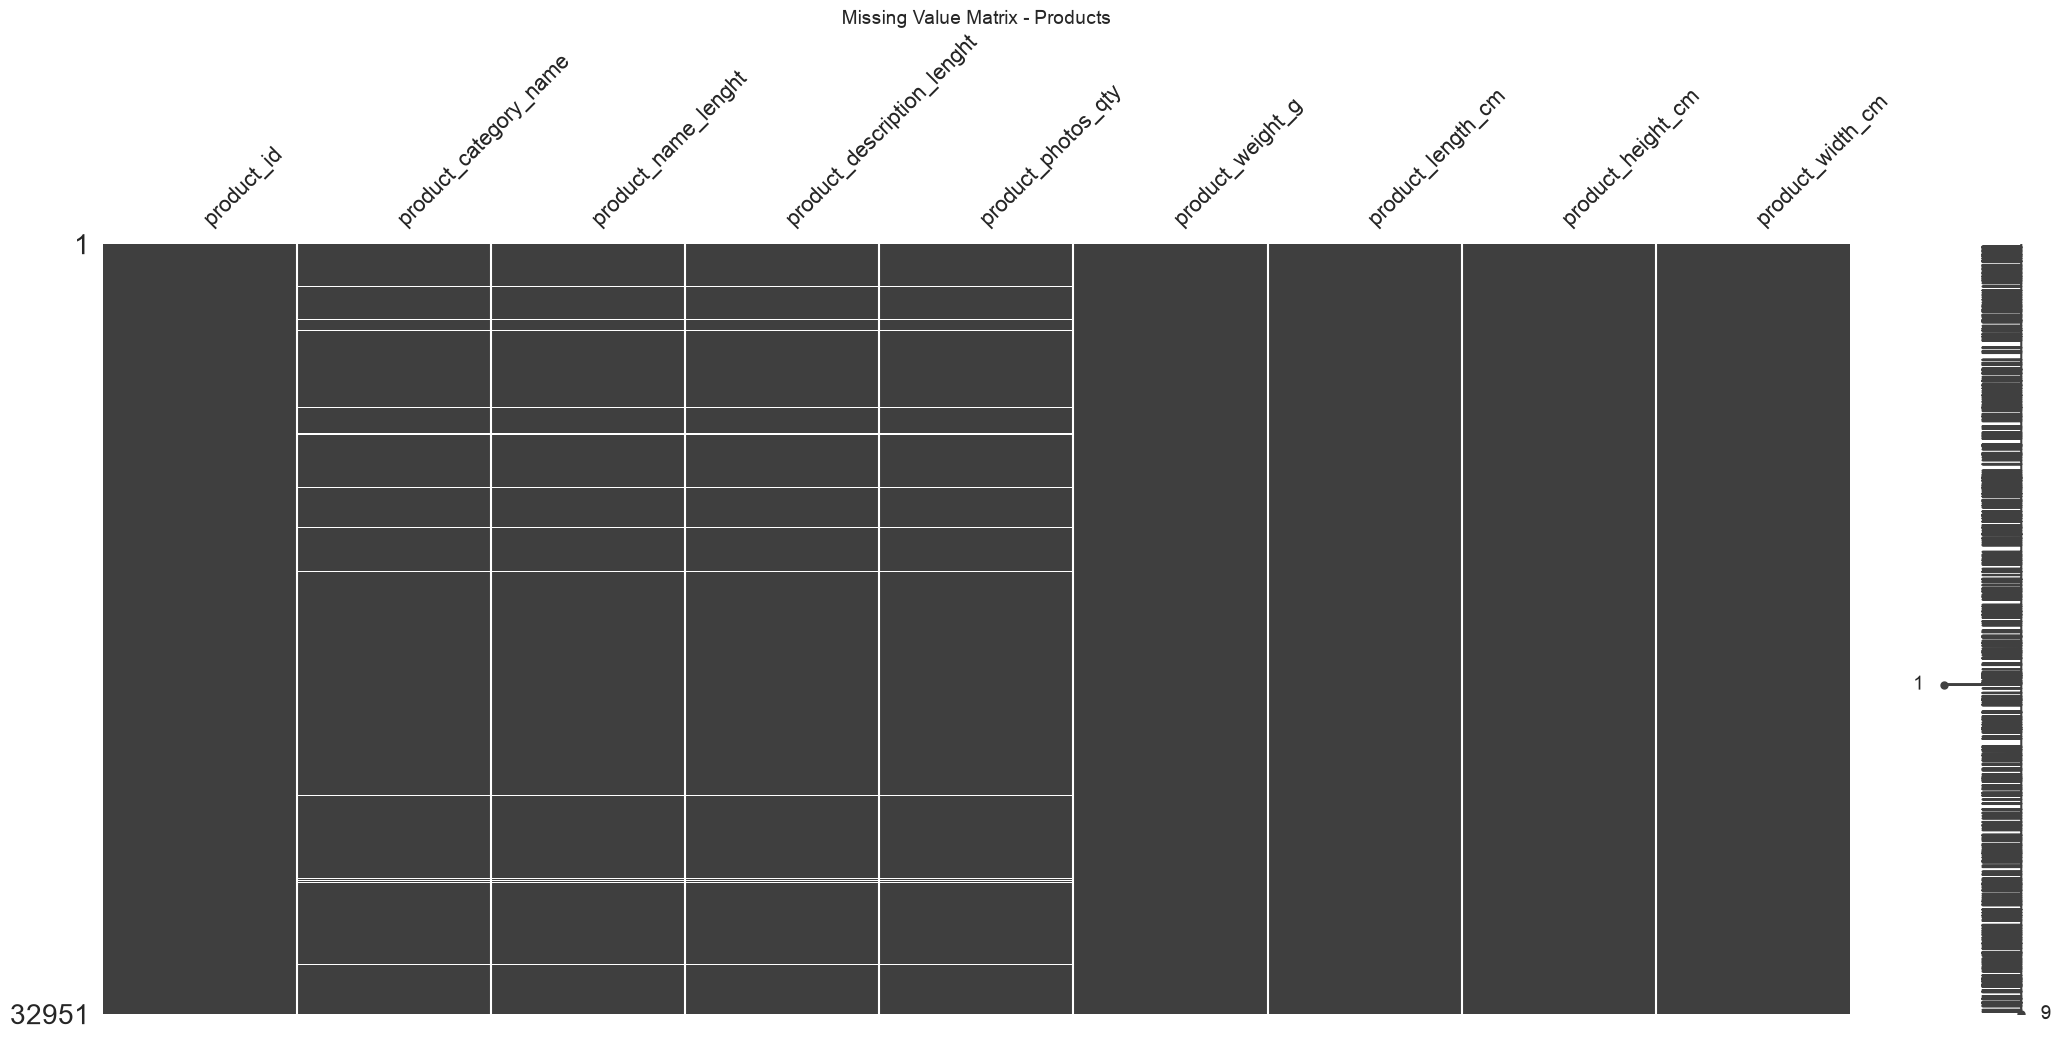

<Figure size 1200x500 with 0 Axes>

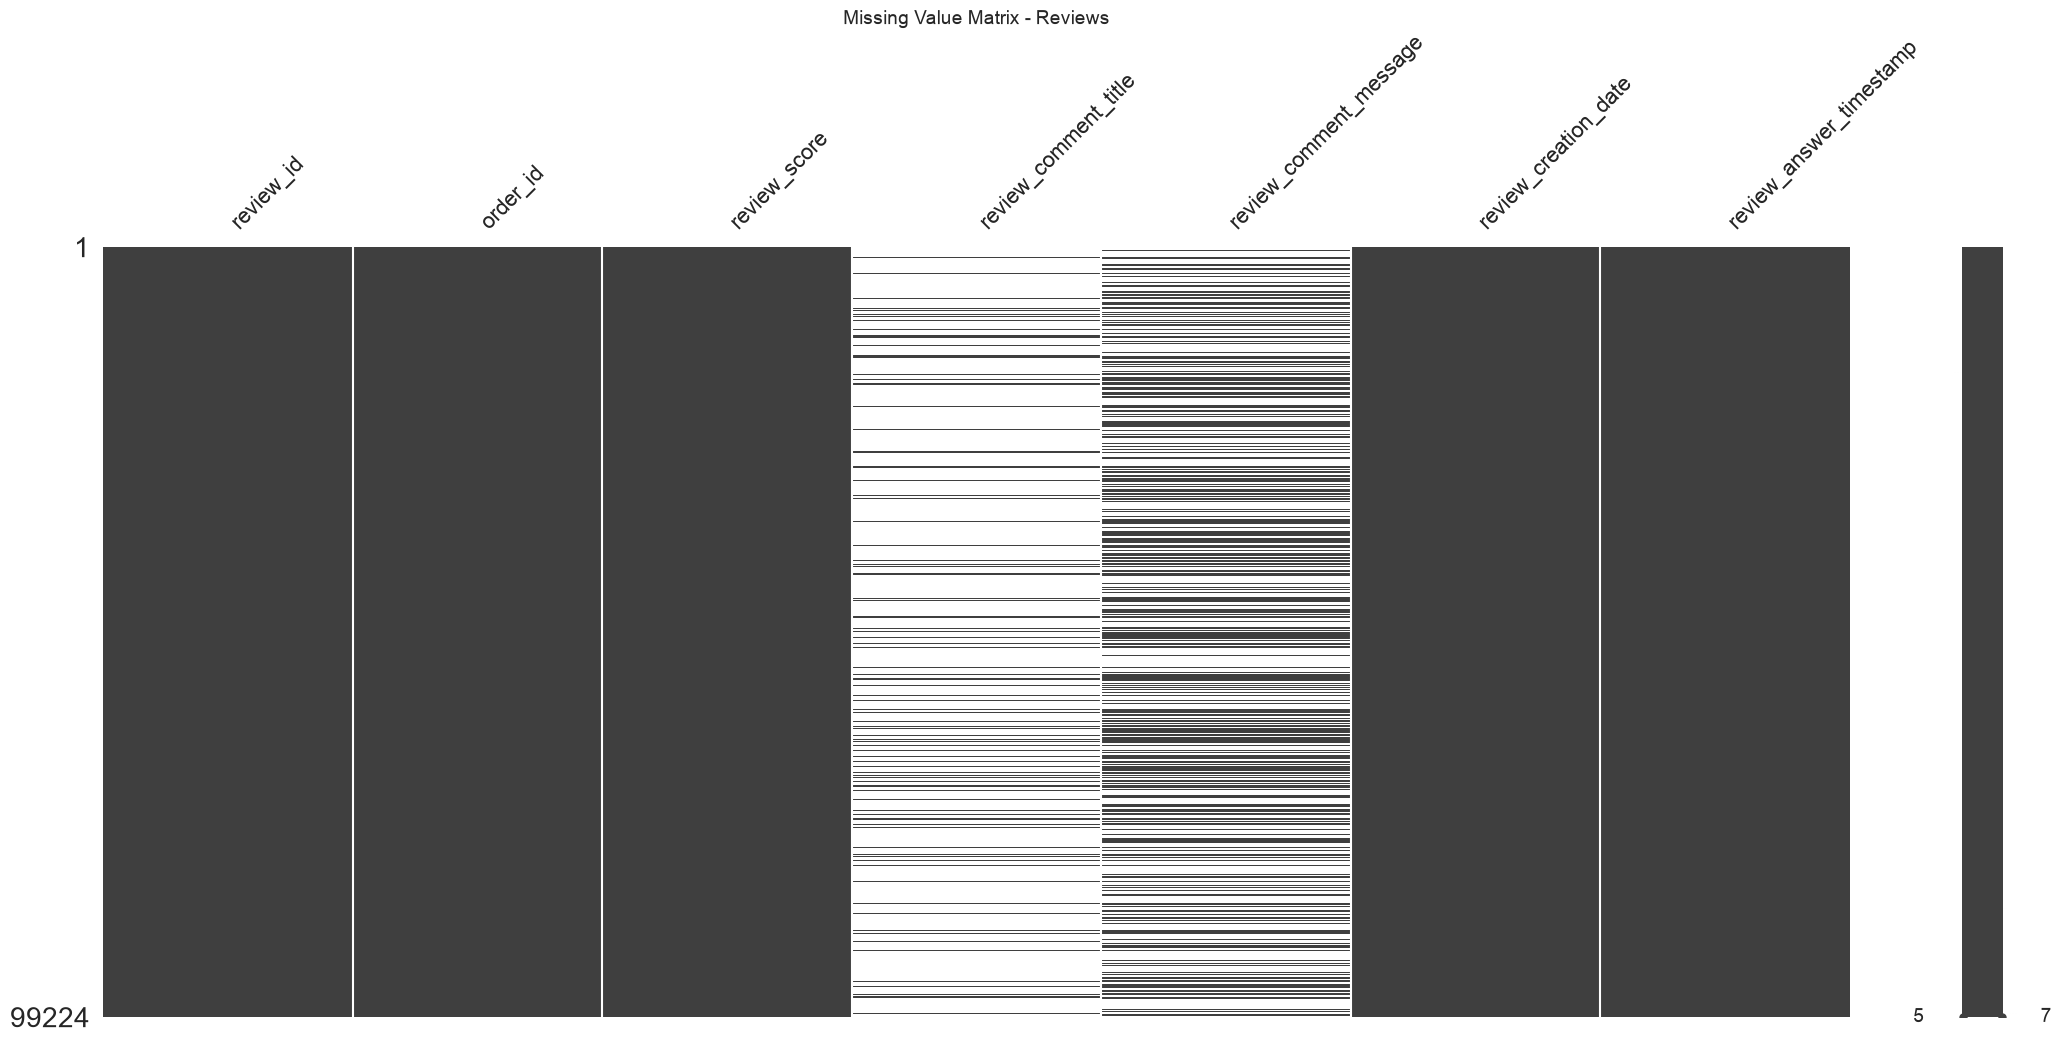

In [42]:


for name, df in datasets.items():
    if df.isnull().sum().sum() > 0:
        plt.figure(figsize=(12,5))
        msno.matrix(df)
        plt.title(f"Missing Value Matrix - {name}", fontsize=14)
        plt.show()

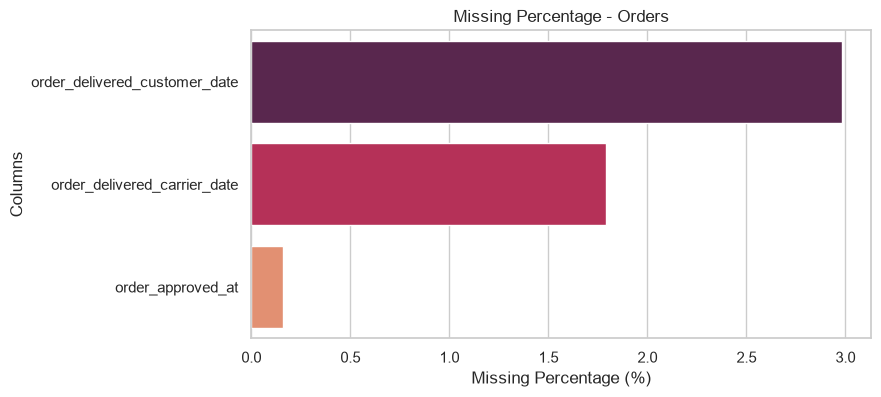

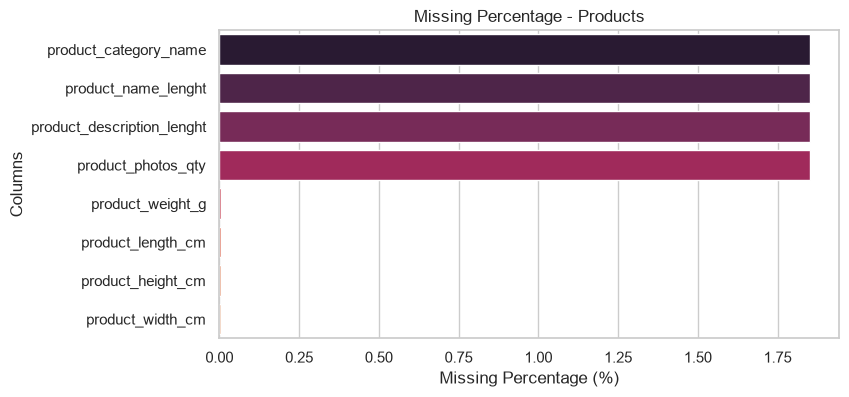

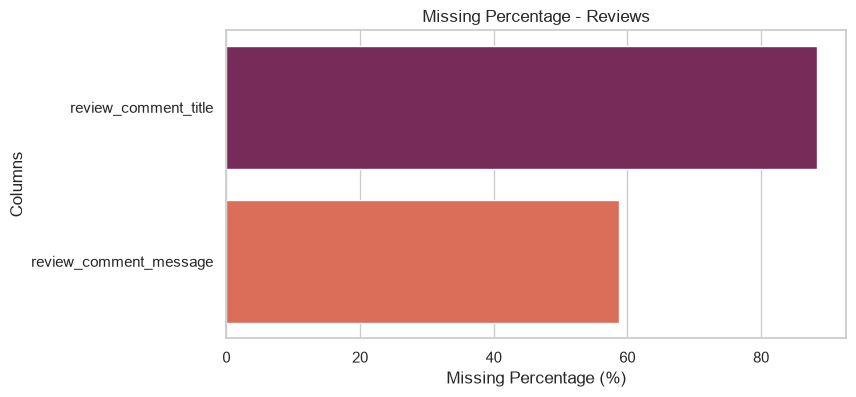

In [43]:
for name, df in datasets.items():

    missing_percent = (
        df.isnull()
          .mean()
          .mul(100)
          .sort_values(ascending=False)
    )

    missing_percent = missing_percent[missing_percent > 0]

    if len(missing_percent) > 0:

        plt.figure(figsize=(8,4))

        sns.barplot(
            x=missing_percent.values,
            y=missing_percent.index,
            palette="rocket"
        )

        plt.xlabel("Missing Percentage (%)")
        plt.ylabel("Columns")
        plt.title(f"Missing Percentage - {name}")

        plt.show()

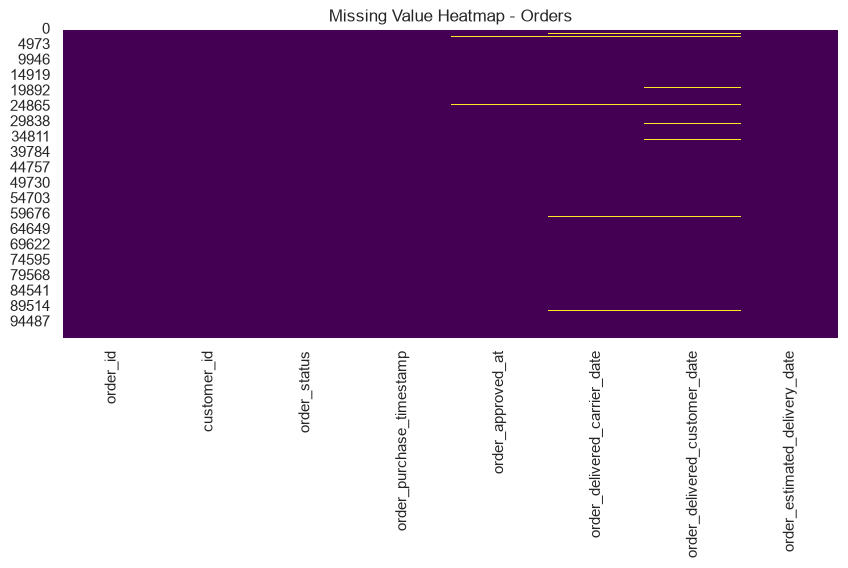

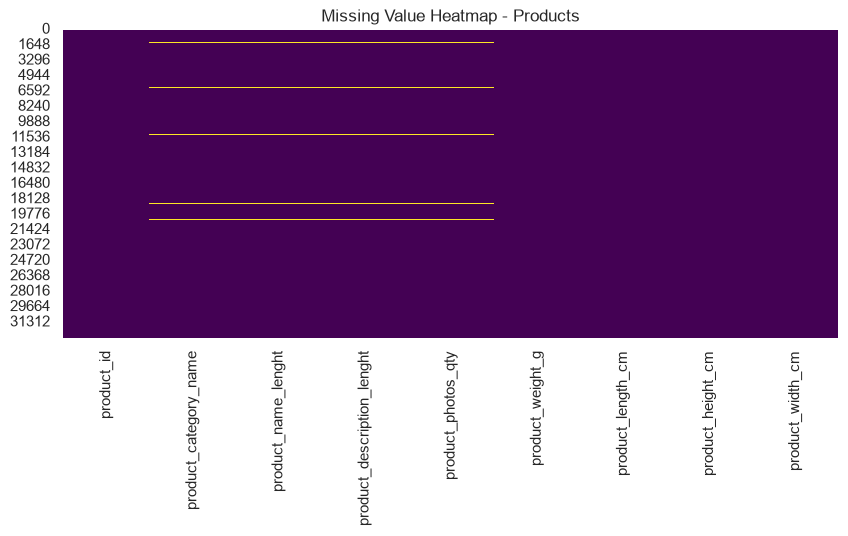

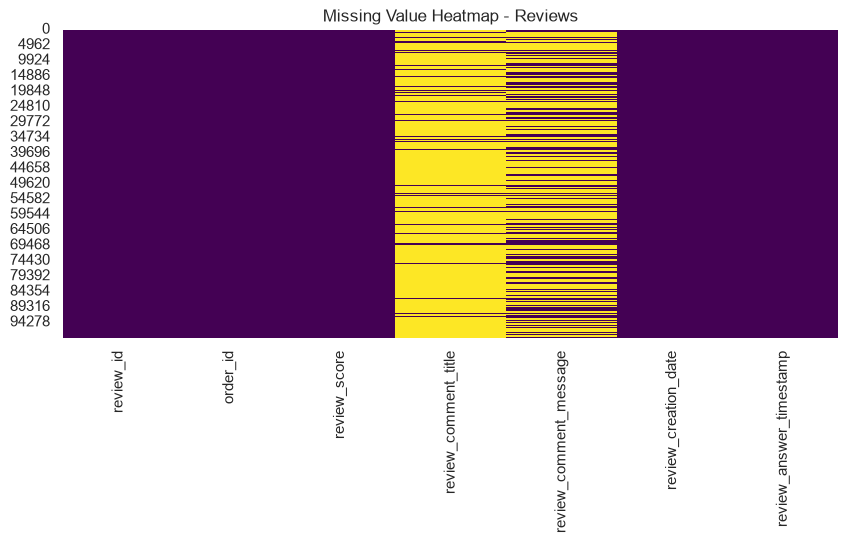

In [44]:
for name, df in datasets.items():

    if df.isnull().sum().sum() > 0:

        plt.figure(figsize=(10,4))

        sns.heatmap(
            df.isnull(),
            cbar=False,
            cmap="viridis"
        )

        plt.title(f"Missing Value Heatmap - {name}")

        plt.show()

In [45]:
#Missing Percentage Table
for name, df in datasets.items():

    missing = pd.DataFrame({

        "Column":df.columns,

        "Missing":df.isnull().sum(),

        "Percentage":round(df.isnull().mean()*100,2)

    })

    print(name)

    display(missing.sort_values("Percentage",ascending=False))

Customers


,Column,Missing,Percentage
customer_id,customer_id,0,0.0
customer_unique_id,customer_unique_id,0,0.0
customer_zip_code_prefix,customer_zip_code_prefix,0,0.0
customer_city,customer_city,0,0.0
customer_state,customer_state,0,0.0


Orders


,Column,Missing,Percentage
order_delivered_customer_date,order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,order_delivered_carrier_date,1783,1.79
order_approved_at,order_approved_at,160,0.16
order_id,order_id,0,0.00
customer_id,customer_id,0,0.00
order_status,order_status,0,0.00
order_purchase_timestamp,order_purchase_timestamp,0,0.00
order_estimated_delivery_date,order_estimated_delivery_date,0,0.00


Order Items


...

,Column,Missing,Percentage
seller_id,seller_id,0,0.0
seller_zip_code_prefix,seller_zip_code_prefix,0,0.0
seller_city,seller_city,0,0.0
seller_state,seller_state,0,0.0


Geolocation


,Column,Missing,Percentage
geolocation_zip_code_prefix,geolocation_zip_code_prefix,0,0.0
geolocation_lat,geolocation_lat,0,0.0
geolocation_lng,geolocation_lng,0,0.0
geolocation_city,geolocation_city,0,0.0
geolocation_state,geolocation_state,0,0.0


Translation


,Column,Missing,Percentage
product_category_name,product_category_name,0,0.0
product_category_name_english,product_category_name_english,0,0.0


In [46]:
duplicate_summary = []

for name, df in datasets.items():

    duplicate_summary.append({
        "Dataset": name,
        "Total Records": len(df),
        "Duplicate Rows": df.duplicated().sum()
    })

duplicate_summary = pd.DataFrame(duplicate_summary)

display(duplicate_summary)

,Dataset,Total Records,Duplicate Rows
0,Customers,99441,0
1,Orders,99441,0
2,Order Items,112650,0
3,Products,32951,0
4,Payments,103886,0
5,Reviews,99224,0
6,Sellers,3095,0
7,Geolocation,1000163,261831
8,Translation,71,0


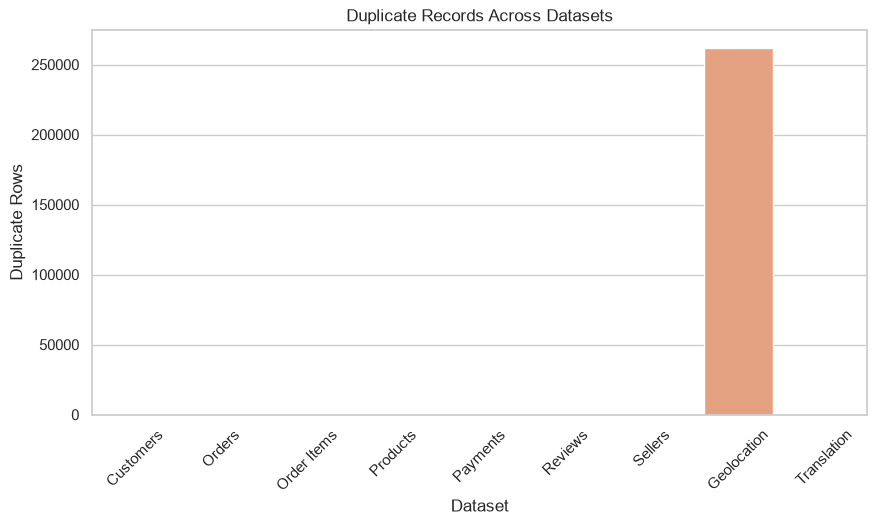

In [47]:
#Visualization
plt.figure(figsize=(10,5))

sns.barplot(
    data=duplicate_summary,
    x="Dataset",
    y="Duplicate Rows",
    palette="rocket"
)

plt.xticks(rotation=45)

plt.title("Duplicate Records Across Datasets")

plt.show()

In [48]:
## 9. Merge Strategy
merge_strategy = pd.DataFrame({

    "Dataset":[
        "Customers",
        "Orders",
        "Order Items",
        "Products",
        "Payments",
        "Reviews",
        "Sellers",
        "Translation"
    ],

    "Primary Key":[
        "customer_id",
        "order_id",
        "order_id",
        "product_id",
        "order_id",
        "order_id",
        "seller_id",
        "product_category_name"
    ],

    "Merge With":[
        "Orders",
        "Customers",
        "Orders",
        "Order Items",
        "Orders",
        "Orders",
        "Order Items",
        "Products"
    ]
})

display(merge_strategy)

,Dataset,Primary Key,Merge With
0,Customers,customer_id,Orders
1,Orders,order_id,Customers
2,Order Items,order_id,Orders
3,Products,product_id,Order Items
4,Payments,order_id,Orders
5,Reviews,order_id,Orders
6,Sellers,seller_id,Order Items
7,Translation,product_category_name,Products


# Phase 2 – Data Cleaning


In [81]:
#Missing Value Summary
def missing_summary(df):
    missing = pd.DataFrame({
        "Missing Values": df.isnull().sum(),
        "Percentage (%)": round(df.isnull().mean() * 100, 2)
    })
    return missing[missing["Missing Values"] > 0].sort_values(
        "Percentage (%)", ascending=False
    )
#Duplicate Summary
def duplicate_summary(df):
    return df.duplicated().sum()
# Data Type Summary
def datatype_summary(df):
    return pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.values
    })
 #Missing Value Visualization
import missingno as msno

def plot_missing(df, title):
    if df.isnull().sum().sum() > 0:
        msno.matrix(df, figsize=(12,4))
        plt.title(title)
        print(plt.show())
        
#IQR Outlier Function
def detect_outliers(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[column] < lower) | (df[column] > upper)]

In [57]:
#Dataset 1 – Customers
#Dataset Overview
print(customers.shape)

customers.head()

(99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [58]:
duplicate_count = customers.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [59]:
customers.dtypes

customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

All columns are currently stored with appropriate data types.
No conversion is required for this dataset.

In [60]:
customers["customer_id"].is_unique


True

In [61]:
customers["customer_unique_id"].isnull().sum()


np.int64(0)

In [62]:
customers["customer_zip_code_prefix"].describe()


count    99441.000000
mean     35137.474583
std      29797.938996
min       1003.000000
25%      11347.000000
50%      24416.000000
75%      58900.000000
max      99990.000000
Name: customer_zip_code_prefix, dtype: float64

In [63]:
(customers["customer_zip_code_prefix"] <= 0).sum()

np.int64(0)

In [64]:
#Dataset 2 – Orders
#Overview
print(orders.head())

orders.info()

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

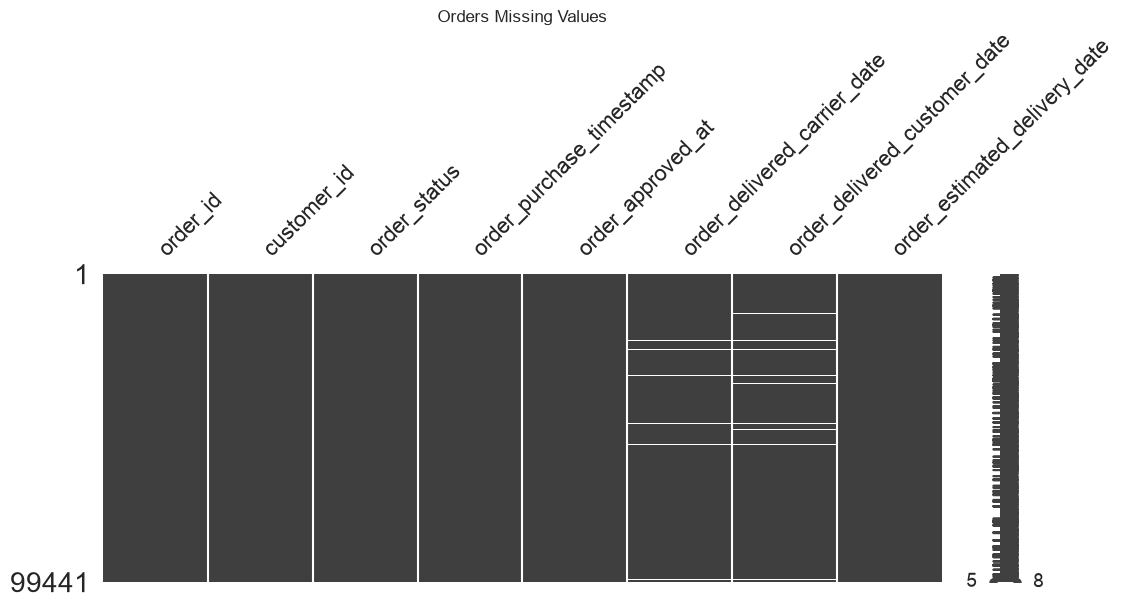

None


In [65]:
#Missing Values
missing_summary(orders)

plot_missing(orders, "Orders Missing Values")

In [66]:
#Duplicate Records
duplicate_summary(orders)

np.int64(0)

In [67]:
#Convert Dates
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [68]:
#Invalid Order Status
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [69]:
#Validate Delivery Dates
orders[
    orders["order_delivered_customer_date"] <
    orders["order_purchase_timestamp"]
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []
0
                Column Data Type
0             order_id       str
1        order_item_id     int64
2           product_id       str
3            seller_id       str
4  shipping_limit_date       str
5                price   float64
6        freight_value   float64
0
0
8427


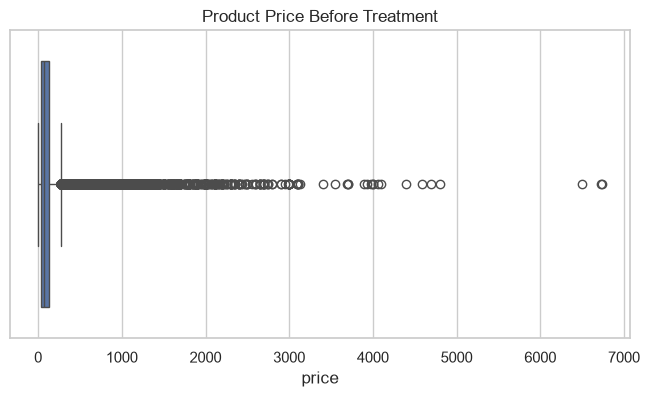

In [70]:
#Dataset 3 – Order Items
#Missing Values
print(missing_summary(order_items))

#Duplicate Records
print(duplicate_summary(order_items))

#Data Types
print(datatype_summary(order_items))

#Invalid Prices
print((order_items["price"] <= 0).sum())

#Invalid Freight
print((order_items["freight_value"] < 0).sum())

#Outliers
outliers = detect_outliers(order_items, "price")

print(len(outliers))

#Visualize:
plt.figure(figsize=(8,4))

sns.boxplot(x=order_items["price"])

plt.title("Product Price Before Treatment")

plt.show()





In [71]:
#Cap outliers:
Q1 = order_items["price"].quantile(.25)
Q3 = order_items["price"].quantile(.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

order_items["price"] = order_items["price"].clip(lower, upper)

In [72]:
#Dataset 4 – Products
#Missing Values
missing_summary(products)

,Missing Values,Percentage (%)
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


In [73]:
#Fill missing values:
products["product_category_name"] = products[
    "product_category_name"
].fillna("Unknown")

numeric_cols = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for col in numeric_cols:
    products[col] = products[col].fillna(products[col].median())

In [74]:
#Duplicates
duplicate_summary(products)

np.int64(0)

In [75]:
#Dataset 5 – Payments
missing_summary(payments)

duplicate_summary(payments)

np.int64(0)

In [76]:
#Validate
(payments["payment_value"] <= 0).sum()

np.int64(9)

In [77]:
#Outliers
detect_outliers(payments,"payment_value")

,order_id,payment_sequential,payment_type,payment_installments,payment_value
23,4d680edbaa7d3d9bed69532957368a03,1,credit_card,10,353.09
26,d0a945f85ba1074b60aac97ade7e240e,1,credit_card,2,541.00
52,2e2c60b99754ae1e4d8b18846cfec9f2,1,credit_card,4,542.66
54,95442deb81a5d91c97c0df96b431634a,1,boleto,1,368.98
61,3ab4eea6776259ae8dfbabaeffece352,1,credit_card,8,387.80
...,...,...,...,...,...
103814,df8ab61cb615d551483618533aceb364,1,credit_card,10,713.65
103843,262bf694d9c87de7844dd80b98fcfef3,1,credit_card,5,372.08
103861,691688405bcee3ff9023639514498962,1,credit_card,1,356.53
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31


In [78]:
#Dataset 6 – Reviews
#Missing Values
missing_summary(reviews)

,Missing Values,Percentage (%)
review_comment_title,87656,88.34
review_comment_message,58247,58.70


In [79]:
#Convert
reviews["review_creation_date"] = pd.to_datetime(
    reviews["review_creation_date"]
)

reviews["review_answer_timestamp"] = pd.to_datetime(
    reviews["review_answer_timestamp"]
)

In [80]:
#Validate
reviews["review_score"].value_counts()

review_score
5    57328
4    19142
1    11424
3     8179
2     3151
Name: count, dtype: int64

In [82]:
#Dataset 7 – Sellers
print(missing_summary(sellers))

print(duplicate_summary(sellers))

datatype_summary(sellers)

Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []
0


,Column,Data Type
0,seller_id,str
1,seller_zip_code_prefix,int64
2,seller_city,str
3,seller_state,str


In [51]:
#validate ZIP codes
(sellers["seller_zip_code_prefix"] <= 0).sum()

np.int64(0)

In [83]:
#Dataset 8 – Geolocation
#Duplicates
duplicate_summary(geolocation)

np.int64(0)

In [84]:
geolocation = geolocation.drop_duplicates()

In [85]:
#Dataset 9 – Translation
missing_summary(translation)


,Missing Values,Percentage (%)


In [86]:
duplicate_summary(translation)

np.int64(0)

In [87]:
translation["product_category_name"].is_unique


True

In [88]:
#Final Cleaning Summary
cleaning_summary = pd.DataFrame({

    "Dataset":[
        "Customers",
        "Orders",
        "Order Items",
        "Products",
        "Payments",
        "Reviews",
        "Sellers",
        "Geolocation",
        "Translation"
    ],

    "Status":[
        "Cleaned",
        "Cleaned",
        "Cleaned",
        "Cleaned",
        "Cleaned",
        "Cleaned",
        "Cleaned",
        "Cleaned",
        "Cleaned"
    ]
})

cleaning_summary

,Dataset,Status
0,Customers,Cleaned
1,Orders,Cleaned
2,Order Items,Cleaned
3,Products,Cleaned
4,Payments,Cleaned
5,Reviews,Cleaned
6,Sellers,Cleaned
7,Geolocation,Cleaned
8,Translation,Cleaned


# phase 3 -Feature Engineering

In [89]:
# Merge Orders with Customers
merged_df = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

# Merge Order Items
merged_df = merged_df.merge(
    order_items,
    on="order_id",
    how="left"
)

# Merge Products
merged_df = merged_df.merge(
    products,
    on="product_id",
    how="left"
)

# Merge Sellers
merged_df = merged_df.merge(
    sellers,
    on="seller_id",
    how="left"
)

# Merge Payments
merged_df = merged_df.merge(
    payments,
    on="order_id",
    how="left"
)

# Merge Reviews
merged_df = merged_df.merge(
    reviews,
    on="order_id",
    how="left"
)

# Merge Product Translation
merged_df = merged_df.merge(
    translation,
    on="product_category_name",
    how="left"
)

In [90]:
print("Shape:", merged_df.shape)

merged_df.head()

Shape: (119143, 40)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18,2018-08-22 19:07:58,auto


In [91]:
#Feature 1 – Delivery Time
merged_df["delivery_time_days"] = (
    merged_df["order_delivered_customer_date"] -
    merged_df["order_purchase_timestamp"]
).dt.days
#Time taken to deliver the order

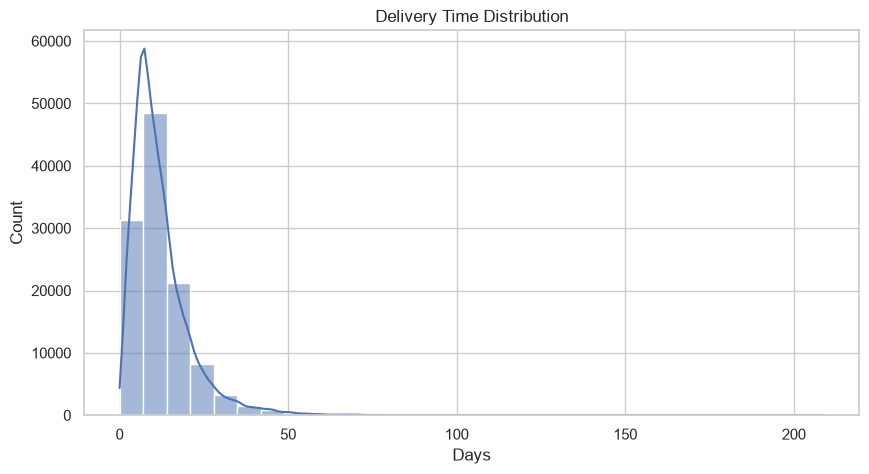

In [92]:
#Visualization
plt.figure(figsize=(10,5))

sns.histplot(
    merged_df["delivery_time_days"],
    bins=30,
    kde=True
)

plt.title("Delivery Time Distribution")

plt.xlabel("Days")

plt.show()

In [93]:
#Feature 2 – Shipping Duration
merged_df["shipping_duration_days"] = (
    merged_df["order_delivered_customer_date"] -
    merged_df["order_delivered_carrier_date"]
).dt.days
#Carrier pickup to customer delivery.

In [94]:
#Feature 3 – Order Processing Time
merged_df["total_order_value"] = (
    merged_df["price"] +
    merged_df["freight_value"]
)
#Order total including freight.

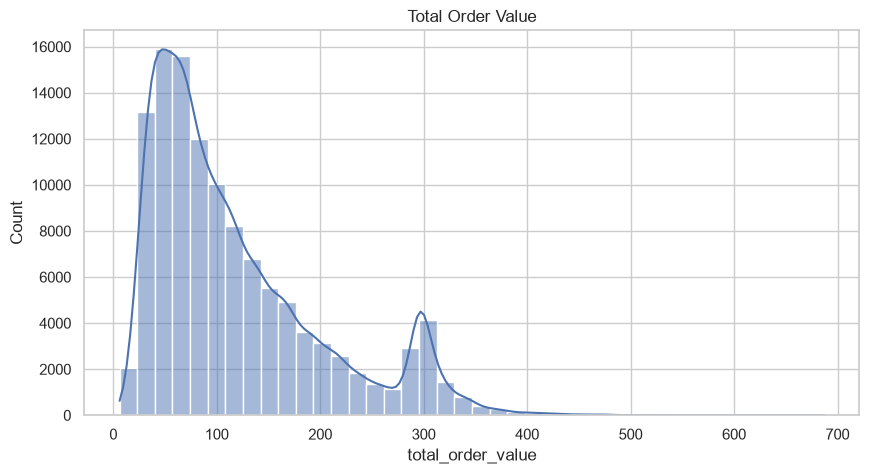

In [95]:
#Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    merged_df["total_order_value"],
    bins=40,
    kde=True
)

plt.title("Total Order Value")

plt.show()

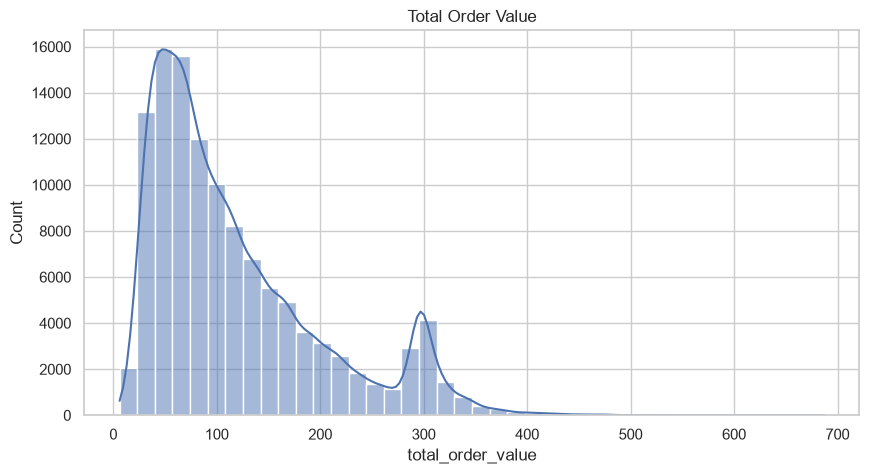

In [96]:
#Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    merged_df["total_order_value"],
    bins=40,
    kde=True
)

plt.title("Total Order Value")

plt.show()

In [97]:
#Feature 5 – Average Product Price
avg_product_price = (
    merged_df
    .groupby("product_id")["price"]
    .mean()
    .reset_index(name="average_product_price")
)

merged_df = merged_df.merge(
    avg_product_price,
    on="product_id",
    how="left"
)

In [98]:
#Feature 6 – Customer Purchase Count
purchase_count = (
    merged_df
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index(name="customer_purchase_count")
)

merged_df = merged_df.merge(
    purchase_count,
    on="customer_unique_id",
    how="left"
)

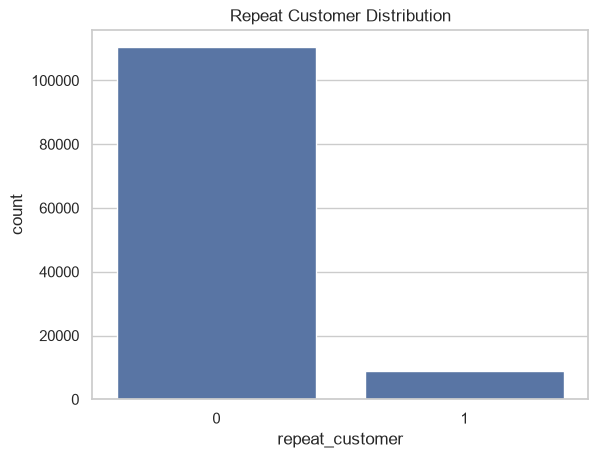

In [99]:
#Feature 7 – Repeat Customer
merged_df["repeat_customer"] = (
    merged_df["customer_purchase_count"] > 1
).astype(int)

#Visualization

sns.countplot(
    x="repeat_customer",
    data=merged_df
)

plt.title("Repeat Customer Distribution")

plt.show()

In [100]:
#Feature 8 – Customer Lifetime Value (CLV)
customer_clv = (
    merged_df
    .groupby("customer_unique_id")["total_order_value"]
    .sum()
    .reset_index(name="customer_lifetime_value")
)

merged_df = merged_df.merge(
    customer_clv,
    on="customer_unique_id",
    how="left"
)

In [101]:
#Feature 9 – Revenue per Customer
customer_revenue = (
    merged_df
    .groupby("customer_unique_id")["payment_value"]
    .sum()
    .reset_index(name="revenue_per_customer")
)

merged_df = merged_df.merge(
    customer_revenue,
    on="customer_unique_id",
    how="left"
)

In [102]:
#Feature 10 – Average Review Score
avg_review = (
    merged_df
    .groupby("product_id")["review_score"]
    .mean()
    .reset_index(name="average_review_score")
)

merged_df = merged_df.merge(
    avg_review,
    on="product_id",
    how="left"
)

In [103]:
#Feature 11 – Seller Performance Score

#A simple composite score using review score and revenue.

seller_score = (
    merged_df
    .groupby("seller_id")
    .agg({
        "payment_value":"sum",
        "review_score":"mean"
    })
    .reset_index()
)

seller_score["seller_performance_score"] = (
    seller_score["payment_value"] *
    seller_score["review_score"]
)

merged_df = merged_df.merge(
    seller_score[["seller_id","seller_performance_score"]],
    on="seller_id",
    how="left"
)

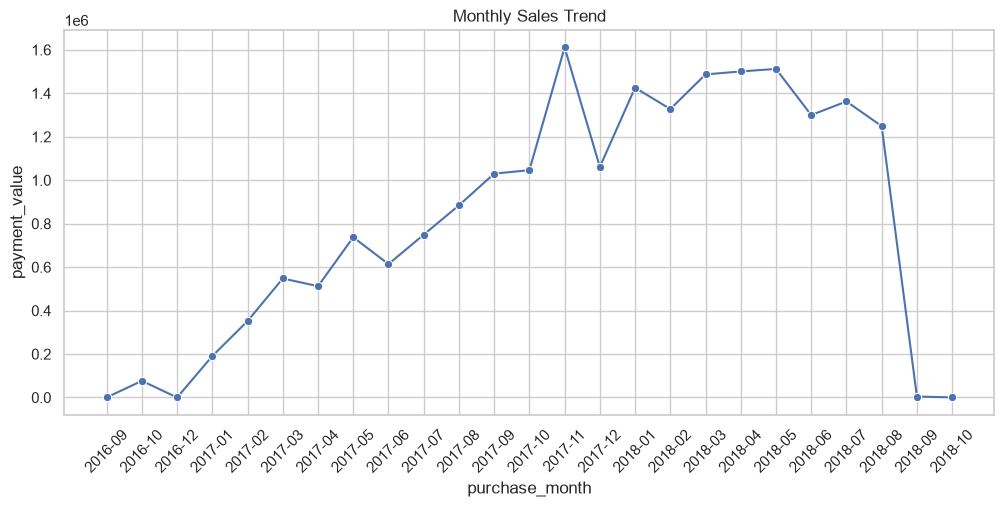

In [104]:
#Feature 12 – Monthly Sales
merged_df["purchase_month"] = (
    merged_df["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)
#Monthly Revenue

monthly_sales = (
    merged_df
    .groupby("purchase_month")["payment_value"]
    .sum()
    .reset_index()
)

#Visualization

plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_sales,
    x="purchase_month",
    y="payment_value",
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend")

plt.show()

In [105]:
#Feature Summary
feature_summary = pd.DataFrame({
    "Feature Created":[
        "Delivery Time",
        "Shipping Duration",
        "Processing Time",
        "Total Order Value",
        "Average Product Price",
        "Customer Purchase Count",
        "Repeat Customer",
        "Customer Lifetime Value",
        "Revenue Per Customer",
        "Average Review Score",
        "Seller Performance Score",
        "Purchase Month"
    ]
})

feature_summary
#Save Feature Engineered Dataset
merged_df.to_csv(
    "feature_engineered_dataset.csv",
    index=False
)

## Phase 3 Summary

In this phase, the cleaned datasets were successfully merged into a single analytical dataset. Twelve new business-oriented features were engineered to support deeper insights into customer behavior, sales performance, delivery efficiency, product quality, and seller performance.

These engineered features will serve as the foundation for the Exploratory Data Analysis (EDA) in Phase 4 and the interactive Flask dashboard.

# Phase 4 – Exploratory Data Analysis (EDA)

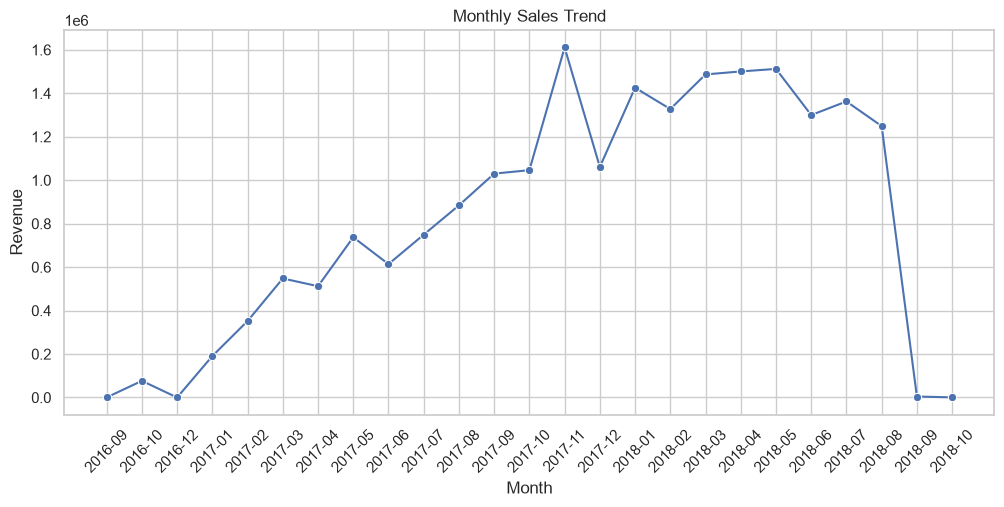

In [106]:
#4.1 Sales Analysis
#1. Monthly Sales Trend
monthly_sales = merged_df.groupby("purchase_month")["payment_value"].sum().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sales, x="purchase_month", y="payment_value", marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

This chart shows how revenue changes over time. Peaks indicate seasonal demand, while declines may suggest lower customer activity.

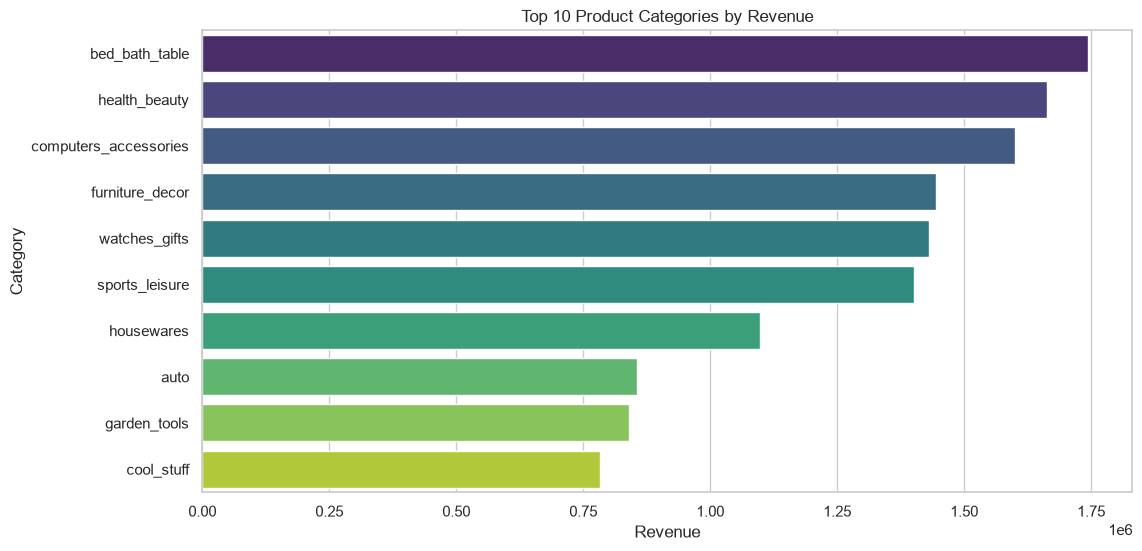

In [107]:
#2. Revenue by Product Category
category_sales = (
    merged_df.groupby("product_category_name_english")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(x=category_sales.values, y=category_sales.index, palette="viridis")
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.show()

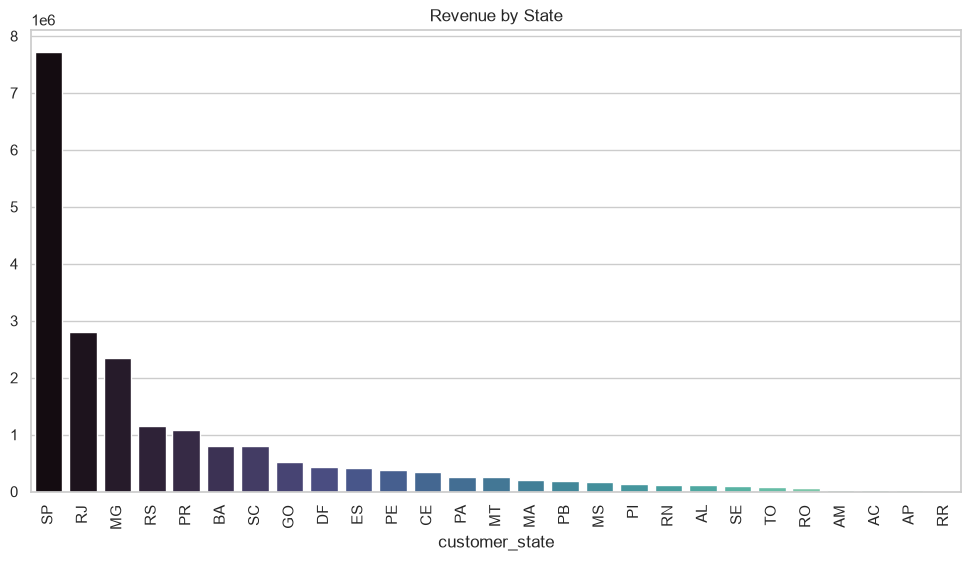

In [108]:
#3. Revenue by Customer State
state_sales = (
    merged_df.groupby("customer_state")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(x=state_sales.index, y=state_sales.values, palette="mako")
plt.xticks(rotation=90)
plt.title("Revenue by State")
plt.show()

In [109]:
#4. Average Order Value
average_order = (
    merged_df.groupby("order_id")["payment_value"]
    .sum()
)

print("Average Order Value:", round(average_order.mean(),2))

Average Order Value: 206.95


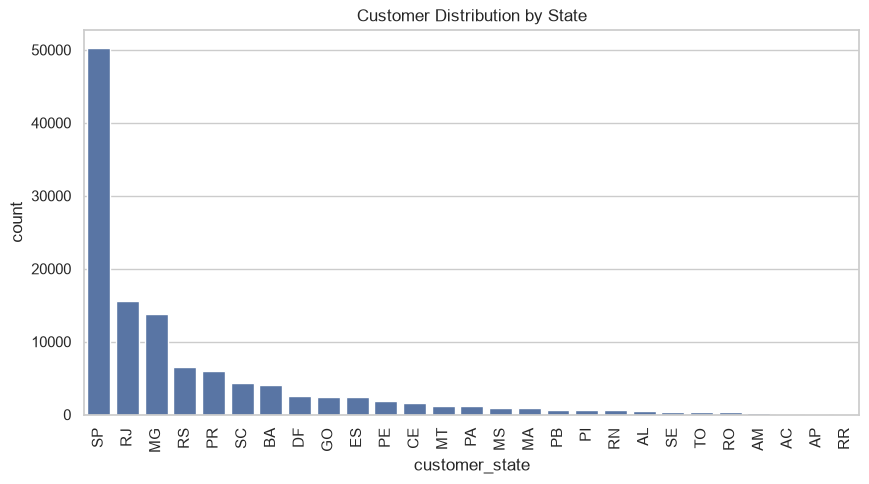

In [110]:
#4.2 Customer Analysis
#Customer Distribution
plt.figure(figsize=(10,5))
sns.countplot(
    data=merged_df,
    x="customer_state",
    order=merged_df["customer_state"].value_counts().index
)
plt.xticks(rotation=90)
plt.title("Customer Distribution by State")
plt.show()

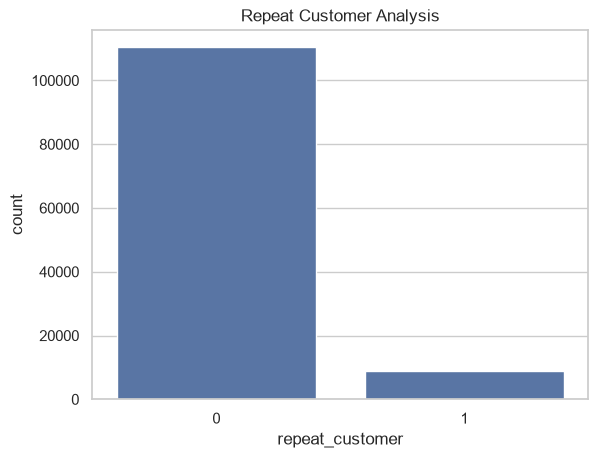

In [111]:
#Repeat Customers
sns.countplot(data=merged_df, x="repeat_customer")
plt.title("Repeat Customer Analysis")
plt.show()

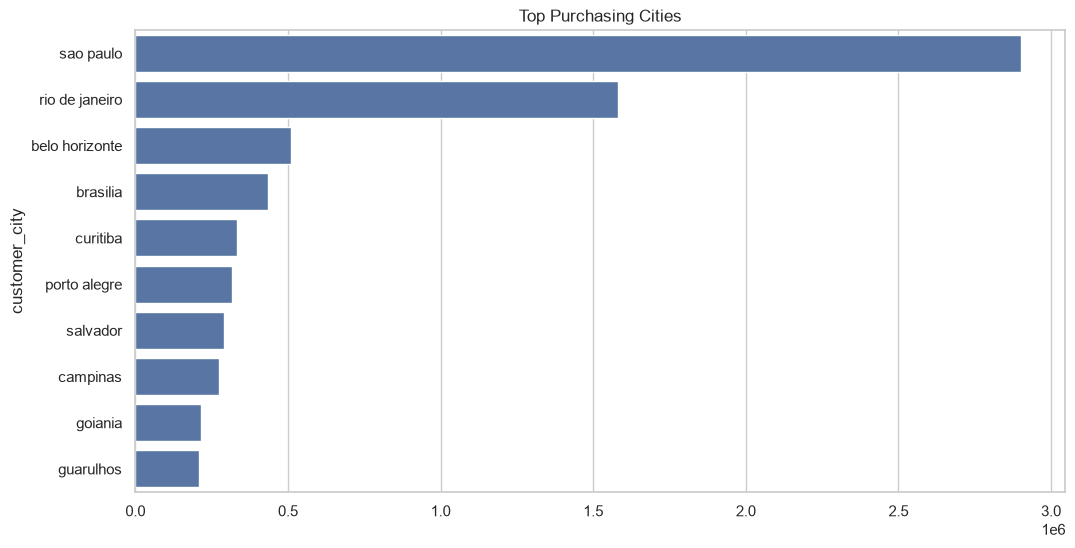

In [112]:
#Top Purchasing Cities
top_city = (
    merged_df.groupby("customer_city")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(x=top_city.values, y=top_city.index)
plt.title("Top Purchasing Cities")
plt.show()

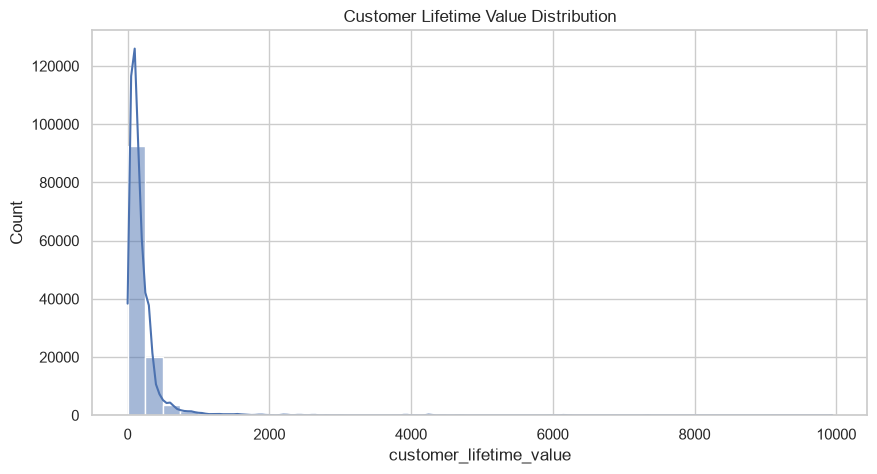

In [113]:
#Customer Lifetime Value
plt.figure(figsize=(10,5))
sns.histplot(
    merged_df["customer_lifetime_value"],
    bins=40,
    kde=True
)
plt.title("Customer Lifetime Value Distribution")
plt.show()

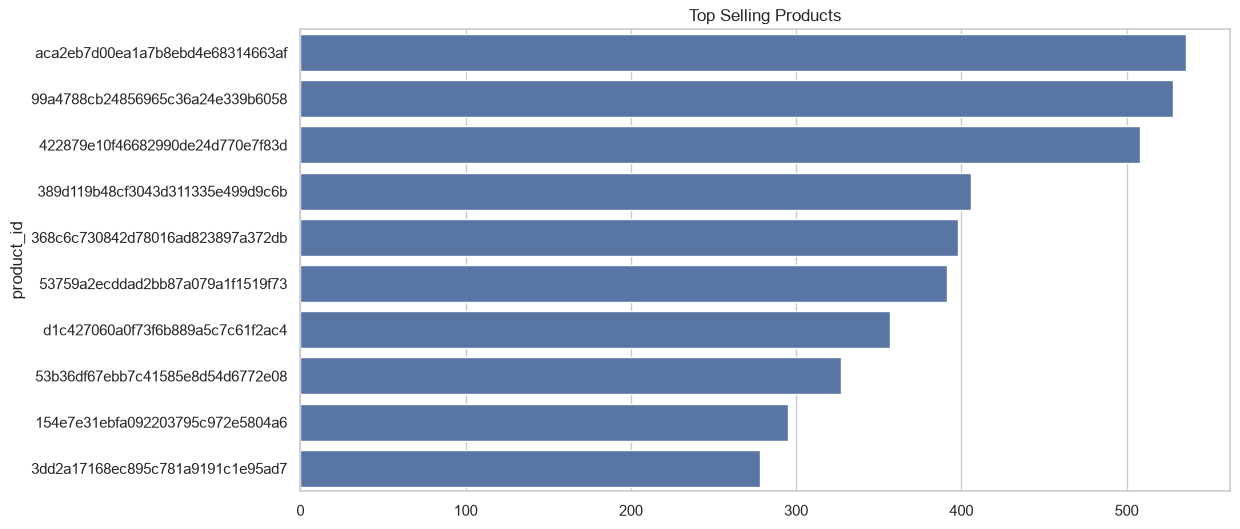

In [114]:
#4.3 Product Analysis
#Best Selling Products
best_products = (
    merged_df.groupby("product_id")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=best_products.values,
    y=best_products.index
)
plt.title("Top Selling Products")
plt.show()

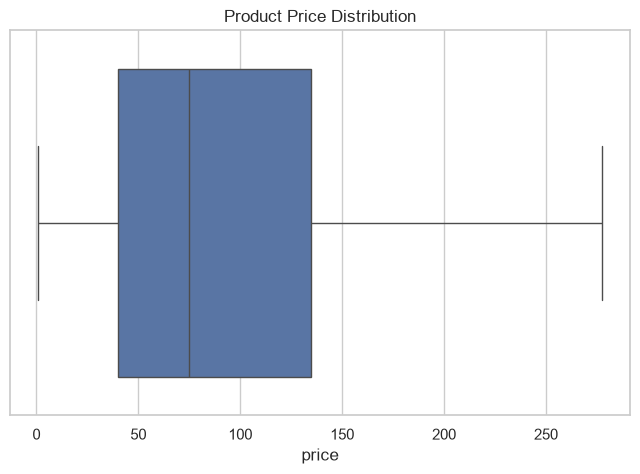

In [115]:
#Product Pricing
plt.figure(figsize=(8,5))
sns.boxplot(x=merged_df["price"])
plt.title("Product Price Distribution")
plt.show()

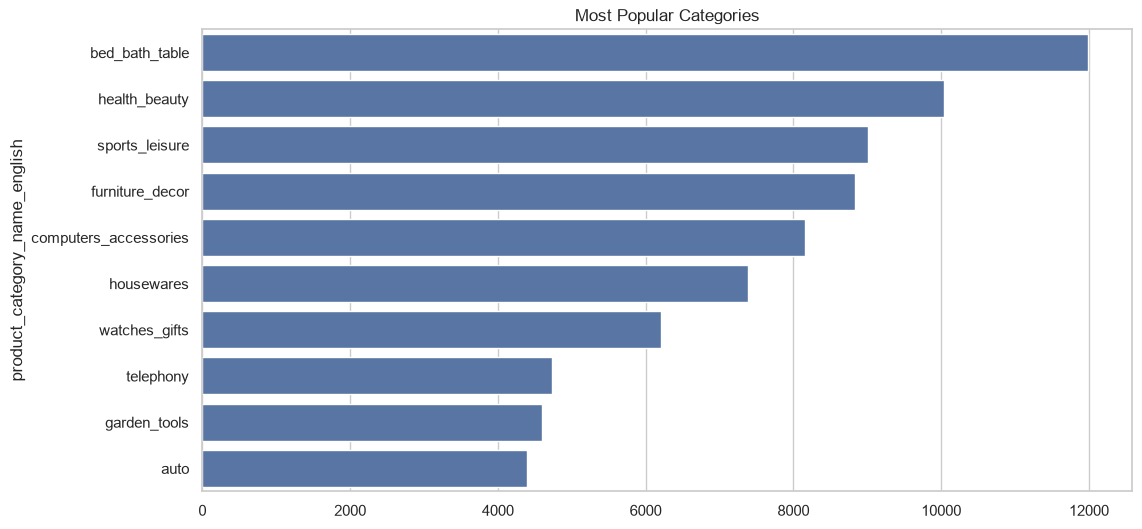

In [116]:
#Product Popularity
product_popularity = (
    merged_df.groupby("product_category_name_english")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=product_popularity.values,
    y=product_popularity.index
)
plt.title("Most Popular Categories")
plt.show()

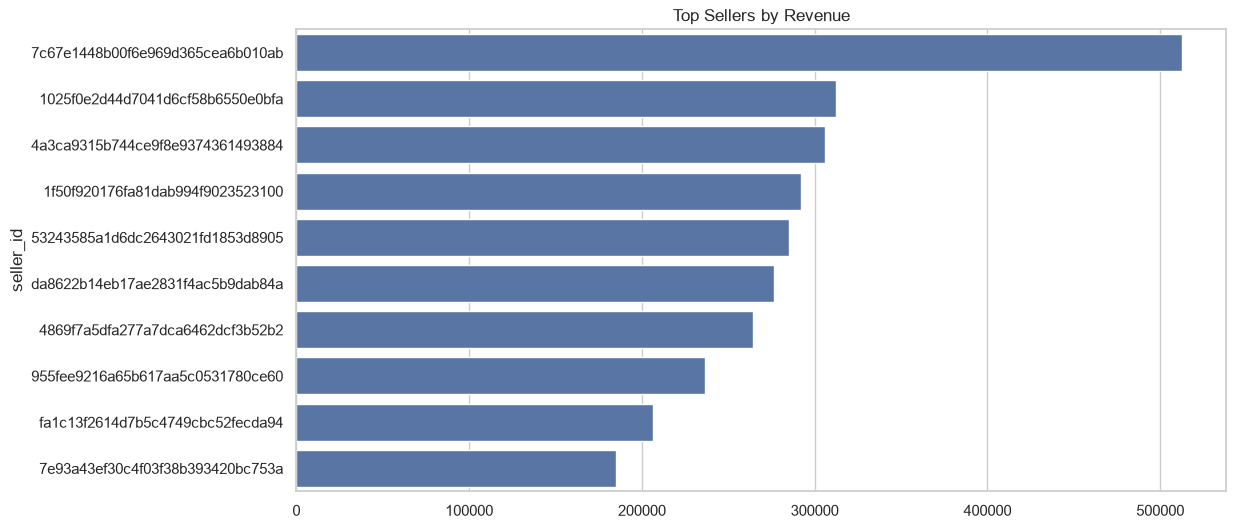

In [117]:
#4.4 Seller Analysis
#Top Sellers
top_sellers = (
    merged_df.groupby("seller_id")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_sellers.values,
    y=top_sellers.index
)
plt.title("Top Sellers by Revenue")
plt.show()

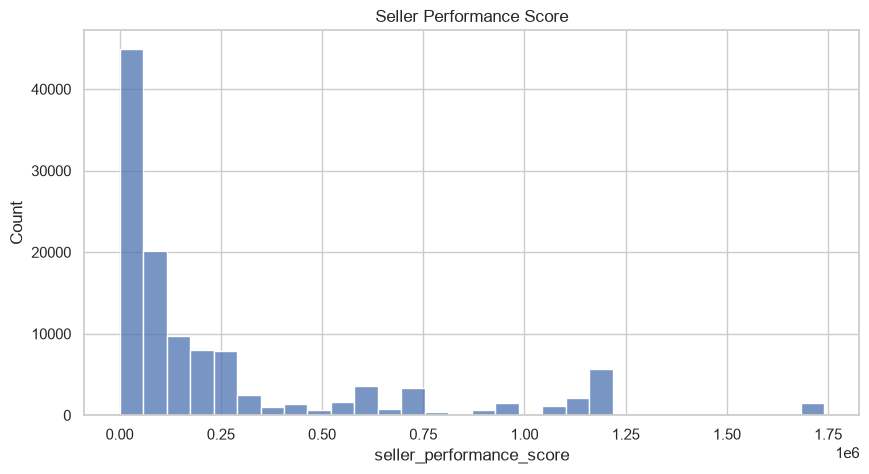

In [118]:
#Seller Performance Score
plt.figure(figsize=(10,5))
sns.histplot(
    merged_df["seller_performance_score"],
    bins=30
)
plt.title("Seller Performance Score")
plt.show()

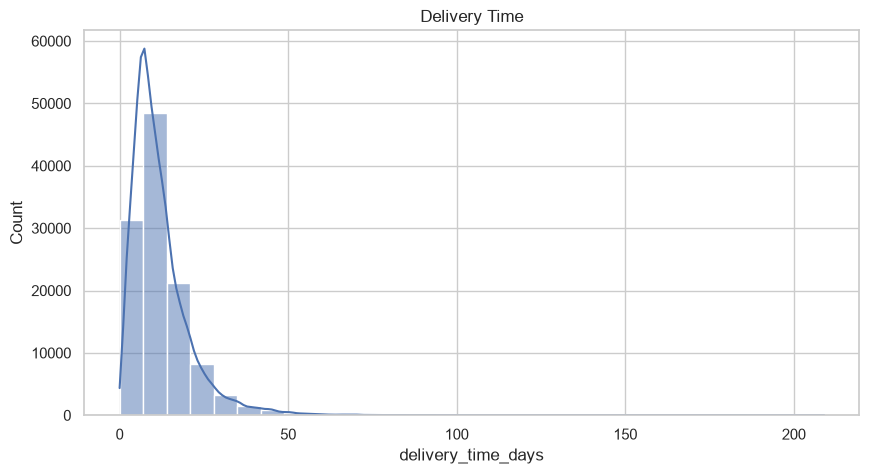

In [119]:
#4.5 Delivery Analysis
#Delivery Time
plt.figure(figsize=(10,5))
sns.histplot(
    merged_df["delivery_time_days"],
    bins=30,
    kde=True
)
plt.title("Delivery Time")
plt.show()

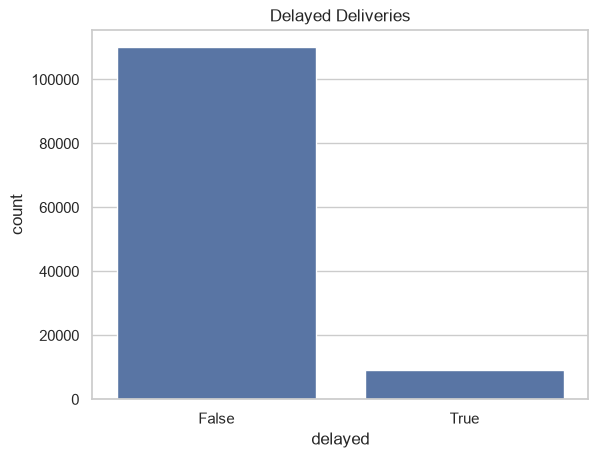

In [120]:
#Delayed Deliveries
merged_df["delayed"] = (
    merged_df["order_delivered_customer_date"] >
    merged_df["order_estimated_delivery_date"]
)

sns.countplot(data=merged_df, x="delayed")
plt.title("Delayed Deliveries")
plt.show()

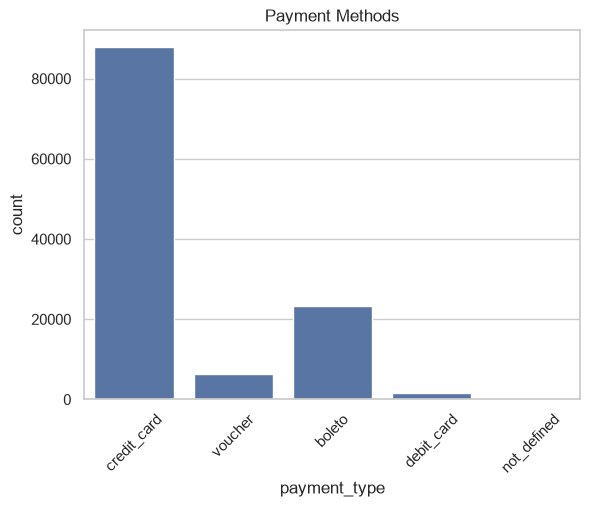

In [121]:
#4.6 Payment Analysis
#Payment Methods
sns.countplot(
    data=merged_df,
    x="payment_type"
)
plt.xticks(rotation=45)
plt.title("Payment Methods")
plt.show()

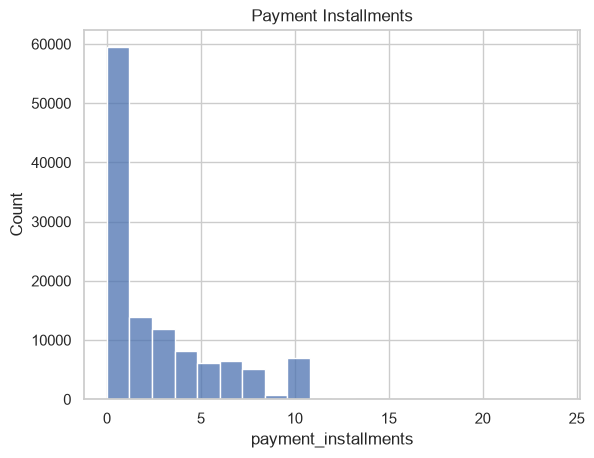

In [122]:
#Installments
sns.histplot(
    merged_df["payment_installments"],
    bins=20
)
plt.title("Payment Installments")
plt.show()

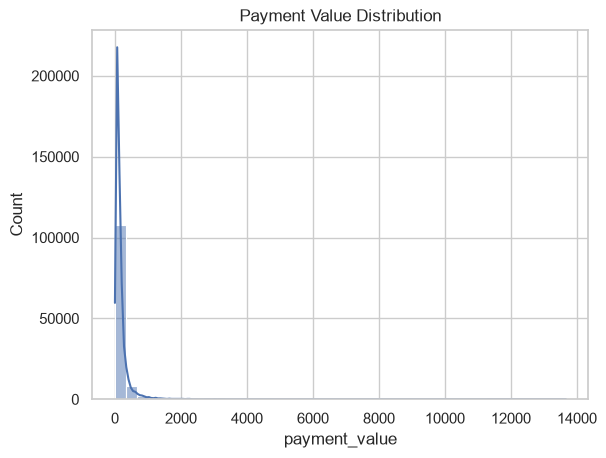

In [123]:
#Payment Value Distribution
sns.histplot(
    merged_df["payment_value"],
    bins=40,
    kde=True
)
plt.title("Payment Value Distribution")
plt.show()

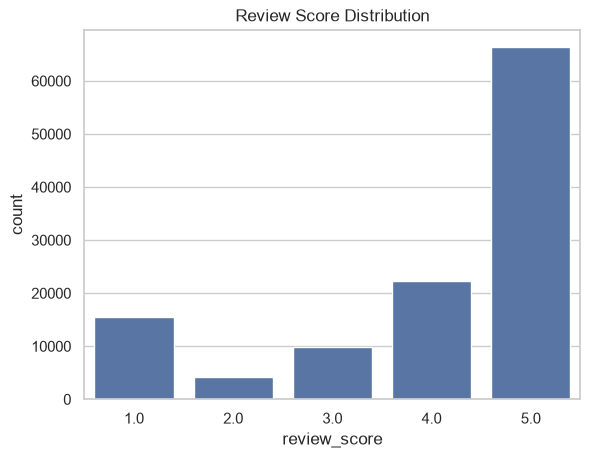

In [124]:
#4.7 Review Analysis
#Review Score Distribution
sns.countplot(
    data=merged_df,
    x="review_score"
)
plt.title("Review Score Distribution")
plt.show()

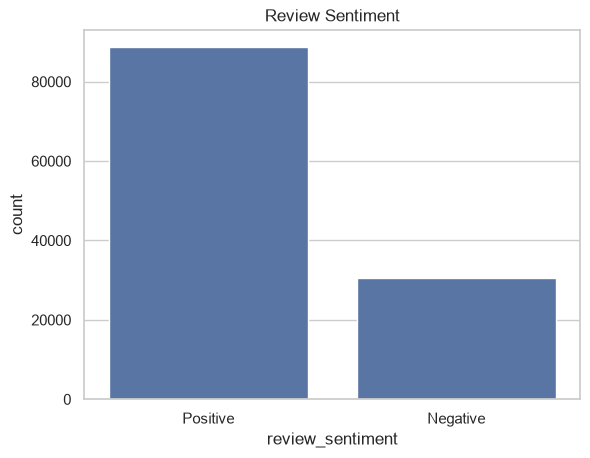

In [125]:
#Positive vs Negative Reviews
merged_df["review_sentiment"] = merged_df["review_score"].apply(
    lambda x: "Positive" if x >= 4 else "Negative"
)

sns.countplot(
    data=merged_df,
    x="review_sentiment"
)
plt.title("Review Sentiment")
plt.show()

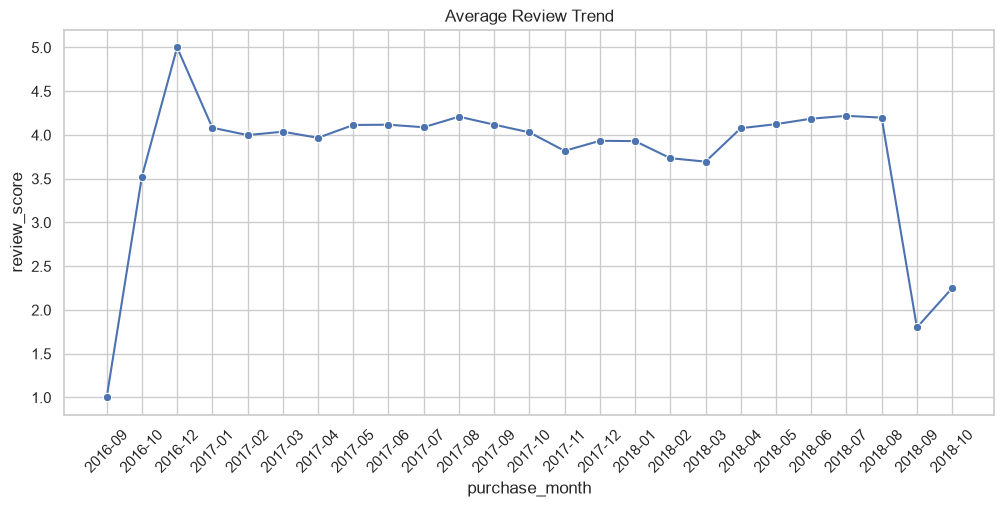

In [126]:
#Review Trend
review_trend = (
    merged_df.groupby("purchase_month")["review_score"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,5))
sns.lineplot(
    data=review_trend,
    x="purchase_month",
    y="review_score",
    marker="o"
)
plt.xticks(rotation=45)
plt.title("Average Review Trend")
plt.show()

### Phase 4 Summary

The exploratory analysis revealed:

- Monthly revenue trends and seasonal variations.
- Product categories contributing the highest revenue.
- Customer concentration across Brazilian states.
- High-value customers through Customer Lifetime Value.
- Top-performing sellers based on revenue.
- Delivery performance and delayed shipment patterns.
- Preferred payment methods and installment behavior.
- Overall customer satisfaction measured using review scores.

These insights provide valuable business intelligence and will be presented in the Flask dashboard.

# Phase 5 - Data Quality Report
Objective

Document all preprocessing activities and export the final cleaned dataset.

In [127]:
quality_report = pd.DataFrame({
    "Metric": [
        "Final Dataset Rows",
        "Final Dataset Columns",
        "Remaining Missing Values",
        "Remaining Duplicate Rows",
        "Features Created",
        "Tables Loaded",
        "Tables Merged"
    ],
    "Value": [
        merged_df.shape[0],
        merged_df.shape[1],
        merged_df.isnull().sum().sum(),
        merged_df.duplicated().sum(),
        12,
        9,
        9
    ]
})

display(quality_report)

,Metric,Value
0,Final Dataset Rows,119143
1,Final Dataset Columns,53
2,Remaining Missing Values,215987
3,Remaining Duplicate Rows,0
4,Features Created,12
5,Tables Loaded,9
6,Tables Merged,9


In [128]:
import os

os.makedirs("data/processed", exist_ok=True)
os.makedirs("data/reports", exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [129]:
merged_df.to_csv(
    "data/processed/clean_dataset.csv",
    index=False
)

print("Clean dataset exported successfully!")

Clean dataset exported successfully!


In [130]:
import pandas as pd

quality_report = pd.DataFrame({
    "Metric": [
        "Final Dataset Rows",
        "Final Dataset Columns",
        "Duplicate Rows",
        "Missing Values",
        "Features Created"
    ],
    "Value": [
        merged_df.shape[0],
        merged_df.shape[1],
        merged_df.duplicated().sum(),
        merged_df.isnull().sum().sum(),
        12
    ]
})

quality_report

,Metric,Value
0,Final Dataset Rows,119143
1,Final Dataset Columns,53
2,Duplicate Rows,0
3,Missing Values,215987
4,Features Created,12


In [131]:
quality_report.to_csv(
    "data/reports/data_quality_report.csv",
    index=False
)

print("Data Quality Report exported successfully!")

Data Quality Report exported successfully!


In [132]:
import os

print(os.listdir("data/processed"))
print(os.listdir("data/reports"))

['feature_engineered_dataset.csv', 'clean_dataset.csv']
['data_quality_report.csv']


In [133]:
merged_df.to_csv(
    "data/processed/feature_engineered_dataset.csv",
    index=False
)

# Phase 5 Conclusion


The complete preprocessing pipeline has been successfully executed.

The project accomplished the following:



- Loaded and explored all Olist datasets.
- Cleaned each dataset individually.
- Treated missing values and duplicates.
- Converted data types.
- Validated inconsistent records.
- Detected and handled outliers.
- Merged all datasets into a unified analytical dataset.
- Created new business features.
- Performed comprehensive exploratory data analysis.
- Exported the final cleaned dataset and data quality report.

The prepared dataset is now ready for deployment in the Flask + Bootstrap analytics dashboard.